In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Пусть $\xi_1, \xi_2,...$ - последовательность независимых случайных величин из хи-квадрат распределения с 3 степенями свободы.   
### Привести графическую иллюстрацию закона больших чисел.

Начнем с определений, что вообще такое хи-квадрат распределение с 3 степенями свободы?

**Определение** - $\chi^2$ распределение с $k \in \mathbb{N}$ степенями свободы - это распределение суммы квадратов $k$ независимых стандартных нормальных случайных величин, т.е. такого набора $\zeta_1, \zeta_2,... : \zeta_i \sim N(0,1) \ i \in \{1,2,...k\}$

Соответственно, функция распределения $\xi \sim \chi^2 = \sum{\zeta_i^2}, \ \zeta_i \sim N(0,1), \ i \in \{1,2,...,k\}$ - это   
$F_{\xi}(t) = \mathbb{P}(\xi \in (-\infty, t)) = \mathbb{P}(\xi < t)$

$\chi^2(k)$ распределение - это частный случай Гамма распределения, в частности: $\xi \sim \chi^2(k) \Longrightarrow \xi \sim Gamma(a=\frac{k}{2}, \theta = 2)$ 

С распределением вроде разобрались. Построим себе для наглядности графики функции распределения  
 и плотности для каждого $\zeta_i$

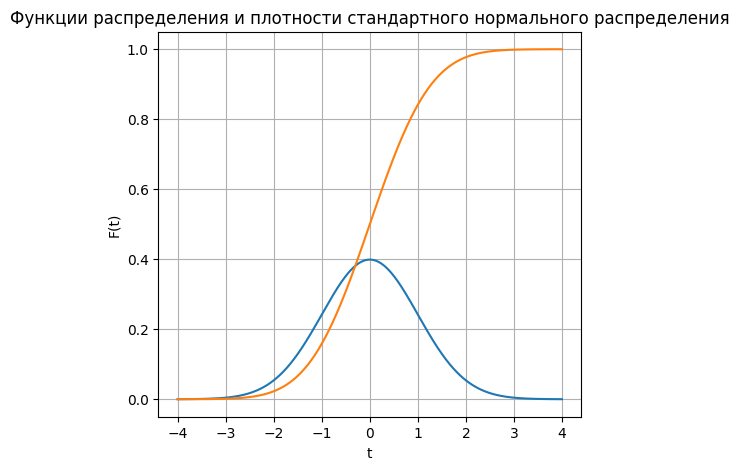

In [2]:
"""
Воспользуемся для этого библиотекой scipy
"""

from scipy.stats import norm

t = np.linspace(-4,4,1000)

pdf = norm.pdf(t)
cdf = norm.cdf(t)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(t, pdf)
plt.title("Функция плотности стандартного нормального распределения")
plt.xlabel("t")
plt.ylabel("f(t)")

plt.subplot(1,2,1)
plt.plot(t, cdf)
plt.title("Функции распределения и плотности стандартного нормального распределения")
plt.xlabel("t")
plt.ylabel("F(t)")
plt.grid()

plt.show()

Нас просят привести графическую интерпретацию закона больших чисел. Давайте вспомним, что это такое!

Говорим, что последовательность случайных величин $\xi_1, \xi_2,...$ с конечными первыми моментами (т.е. $\mathbb{E}(\xi_i) < \infty , \ i \in \mathbb{N})$ удовлетворяет **закону больших чисел** **(ЗБЧ)**, если:   
$$\frac{\xi_1 + ... + \xi_n}{n} - \frac{\mathbb{E}(\xi_1)+...+\mathbb{E}(\xi_n)}{n} \xrightarrow{p} 0, \ n \rightarrow \infty \ \ (1)$$

Где последовательность случайных величин $\zeta_n \xrightarrow{p} 0 , \ n \rightarrow \infty \Longleftrightarrow$   
$\Longleftrightarrow \forall \epsilon > 0 \ : \ \mathbb{P}(|\zeta_n - 0| \geq \epsilon) \rightarrow 0 \ , \ n \rightarrow \infty \equiv \forall \epsilon > 0 \ : \ \mathbb{P}(|\zeta_n| \geq \epsilon) \rightarrow 0 \ , \ n \rightarrow \infty$

Соответственно **законами больших чисел** принято называть утверждения о том, **при каких условиях** последовательность случайных величин удовлетворяет **закону больших чисел**, т.е. выполняется свойство (1)

По условию задачи мы работаем с последовательностью независимых и одинаково распределенных случайных величин, соответственно, можно воспользоваться **ЗБЧ Чебышёва**:     
$$ \frac{\xi_1 + ... + \xi_n}{n} \xrightarrow{p} \mathbb{E}(\xi_1) \ , n \rightarrow \infty \ \ \ (2)$$

Для его выполнения нам нужно требовать конечность первого момента $\xi_i$, поэтому давайте посчитаем его.

$\xi_i = \xi_1 = \xi \sim \chi^2(3) \Longrightarrow \xi = \zeta_1^2 + \zeta_2^2 + ... + \zeta_k^2, \ \zeta_i = \zeta \sim N(0,1) \Longrightarrow$  
$$\Longrightarrow \mathbb{E}(\xi) = \mathbb{E}(\sum_{i=1}^{k=3}{(\zeta_i^2)}) = \sum_{i=1}^{k=3}{\mathbb{E}(\zeta_i^2)} = \sum_{i=1}^{k=3}{1} = k = 3\Longrightarrow$$
$\Longrightarrow \mathbb{E}(\xi) = 3 \Longrightarrow \mathbb{E}(S_n) = 3n$

Аналогичными рассуждениями определим дисперсию $\xi_i$  
$\xi_i = \xi_1 = \xi \sim \chi^2(3) \Longrightarrow \xi = \zeta_1^2 + \zeta_2^2 + ... + \zeta_k^2, \ \zeta_i = \zeta \sim N(0,1) \Longrightarrow$  
$$\Longrightarrow \mathbb{D}(\xi) = \mathbb{D}(\sum_{i=0}^{k=3}{(\zeta_i^2)}) = \sum_{i=1}^{k=3}{\mathbb{D}(\zeta_i^2)} = \sum_{i=1}^{k=3}{\mathbb{E}(\zeta_i^4) - (\mathbb{E}(\zeta_i^2))^2} = \sum_{i=1}^{k=3}{3 - 1} = \sum_{i=1}^{k=3}{2} = 6  \Longrightarrow$$
$\Longrightarrow \mathbb{D}(\xi) = 6 \Longrightarrow \mathbb{D}(S_n) = 6n$

Соответственно, остается показать верность (2) при увеличении n. 

In [3]:
"""
Сгенерируем выборку, из которой будет состоять наша последовательность случайных величин
"""

N = 2000

xi = np.random.chisquare(df=3, size=N)

print(xi)

[ 8.04323927  4.43719068  5.11409595 ...  1.13968577  6.14756457
 10.57128789]


In [4]:
"""
Найдем кумулятивную сумму (S_n) и вычислим выборочное среднее для каждого из n = 1, 2, ... , N
"""

S_n = np.cumsum(xi)

sample_mean = S_n / np.arange(1, N+1)

print(f"S_n = {S_n}, \n")

print(f"sample_mean = {sample_mean}, \n")

S_n = [   8.04323927   12.48042994   17.59452589 ... 5833.37159869 5839.51916326
 5850.09045115], 

sample_mean = [8.04323927 6.24021497 5.86484196 ... 2.9196054  2.92122019 2.92504523], 



In [5]:
"""
Заранее обернем это в функцию
"""

def sample(N):

    xi = np.random.chisquare(df=3, size=N)

    S_n = np.cumsum(xi)

    sample_mean = S_n / np.arange(1, N+1)

    return sample_mean

Зададим на графике вертикальную отсечку, равную той точке, после которой **все** значения выборочного среднего отличаются от ответа не больше, чем стандартное отклоенение. И добавим еще отсечку, по такой же логике, но с const = 0.01.

Чему же будет равно это отклонение? 

$\sigma(\frac{S_n}{n}) = \sqrt{\mathbb{D}(\frac{S_n}{n})} = \sqrt{\frac{6}{n}}$

In [6]:
def illustration(sample_mean):
    N = len(sample_mean)
    print(f"Размер выборки = {N}")
    n = np.arange(1, N + 1)

    target = 3
    eps = 0.01
    sigma_mean = np.sqrt(6 / n)

    # 1) Отсечка по константе 0.01 - булевый массив - если разница меньше, то True
    inside_eps = np.abs(sample_mean - target) <= eps

    # 2) Отсечка по динамической границе sqrt(6/n) - булевый массив - если разница меньше, то True
    inside_sigma = np.abs(sample_mean - target) <= sigma_mean

    # suffix_all_true[i] = True, если начиная с i и до конца все значения True
    suffix_eps = np.flip(np.cumprod(np.flip(inside_eps.astype(int)))).astype(bool)
    suffix_sigma = np.flip(np.cumprod(np.flip(inside_sigma.astype(int)))).astype(bool)

    # Ищем первый индекс, начиная с которого условие выполнено для всех оставшихся
    idx_eps = np.where(suffix_eps)[0]
    idx_sigma = np.where(suffix_sigma)[0]

    plt.figure(figsize=(12, 8))

    plt.plot(n, sample_mean, label=r"$S_n/n$")
    plt.axhline(target, linestyle="--", label=r"$E(\xi)=3$", color="red")

    # Полоса +-0.01
    plt.axhline(target + eps, linestyle=":", color="orange", label=r"$3 \pm 0.01$")
    plt.axhline(target - eps, linestyle=":", color="orange")

    # Полоса +-sqrt(6/n)
    plt.plot(n, target + sigma_mean, linestyle=":", color="green", label=r"$3 \pm \sqrt{6/n}$")
    plt.plot(n, target - sigma_mean, linestyle=":", color="green")

    # Вертикальная отсечка по 0.01
    if len(idx_eps) > 0:
        n_eps = idx_eps[0] + 1
        plt.axvline(n_eps, linestyle="--", color="orange",
                    label=f"отсечка по 0.01: n = {n_eps}")

    # Вертикальная отсечка по sqrt(6/n)
    if len(idx_sigma) > 0:
        n_sigma = idx_sigma[0] + 1
        plt.axvline(n_sigma, linestyle="--", color="purple",
                    label=f"отсечка по $\\sqrt{{6/n}}$: n = {n_sigma}")

    plt.xlabel("n")
    plt.ylabel(r"$S_n/n$")
    plt.title("Иллюстрация закона больших чисел")

    plt.legend()
    plt.grid()
    plt.show()


Сразу сделаем функцию для графика сходимости:  

Будем рассматривать ошибку $e_n = |\frac{S_n}{n} - 3|$  
Положим, что у сходимости метода $p$ порядок, то есть на равномерной сетке с шагом $h$ погрешность является величиной  
$O(h^p)$, т.е. не превосходит $Ch^p$.

Соответственно положим, что $e_n = \frac{C}{n^\alpha} \Longrightarrow e_n = Cn^{-\alpha} \Longrightarrow log(e_n) = log(C) - \alpha \cdot log(n) \Longrightarrow$  
$\Longrightarrow x = log(n), y = log(e_n) \Longrightarrow y = log(C) + \alpha \cdot x \Longrightarrow y = a + bx$

In [7]:
def estimate_rate(sample_mean, target=3, start=10):
    n = np.arange(1, len(sample_mean) + 1)
    err = np.abs(sample_mean - target) #вычислим значение ошибки

    mask = (n >= start) & (err > 0) #избавимся от таких точек, где log берется от 0, а так же, где ошибки нет.
    x = np.log(n[mask])
    y = np.log(err[mask])

    slope, intercept = np.polyfit(x, y, 1) #функция подбирает такие значения, что y = slope * x + intercept
    alpha = -slope
    C = np.exp(intercept)

    return alpha, C, mask, n, err


def plot_estimate_rate(sample_mean, target=3):

    alpha, C, mask, n, err = estimate_rate(sample_mean, target=3, start=10)

    err_fit = C / (n[mask] ** alpha)

    plt.figure(figsize=(12, 8))

    plt.plot(n[mask], err[mask], label=r"$|S_n/n - 3|$")
    plt.plot(n[mask], err_fit, linestyle="--",
             label=fr"$C n^{{-\alpha}}$, $\alpha \approx {alpha:.4f}$")

    plt.xscale("log")
    plt.yscale("log")

    plt.xlabel("n")
    plt.ylabel(r"$|S_n/n - 3|$")
    plt.title("Оценка скорости сходимости")
    plt.legend()
    plt.grid()

    plt.show()

    print(f"alpha ≈ {alpha:.4f}")
    print(f"C ≈ {C:.4f}")
    
    return alpha

Размер выборки = 25


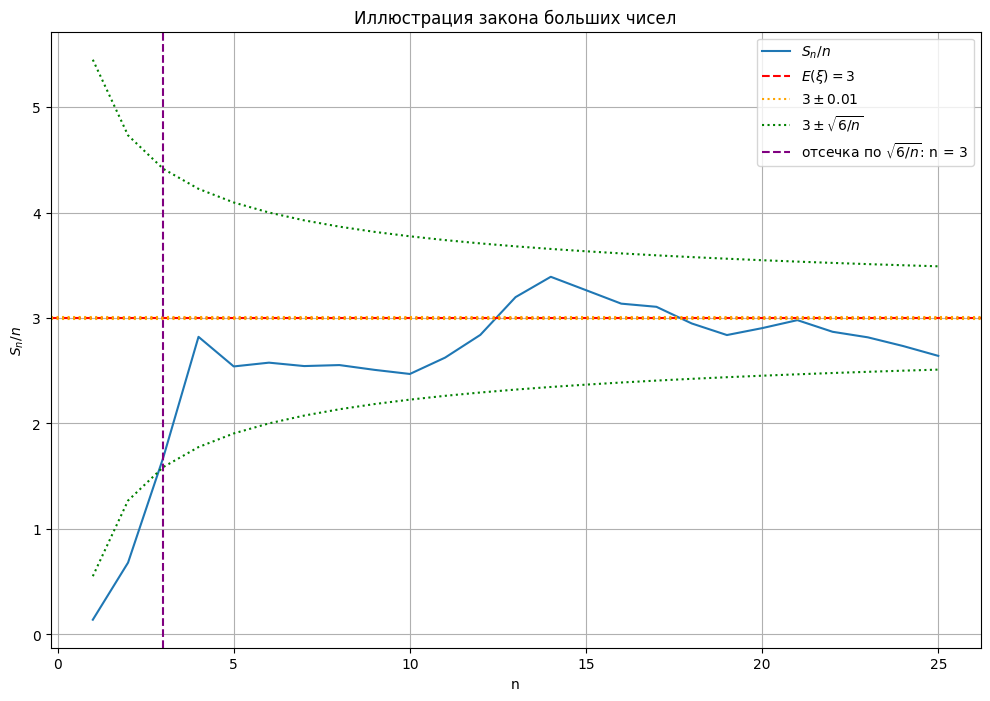

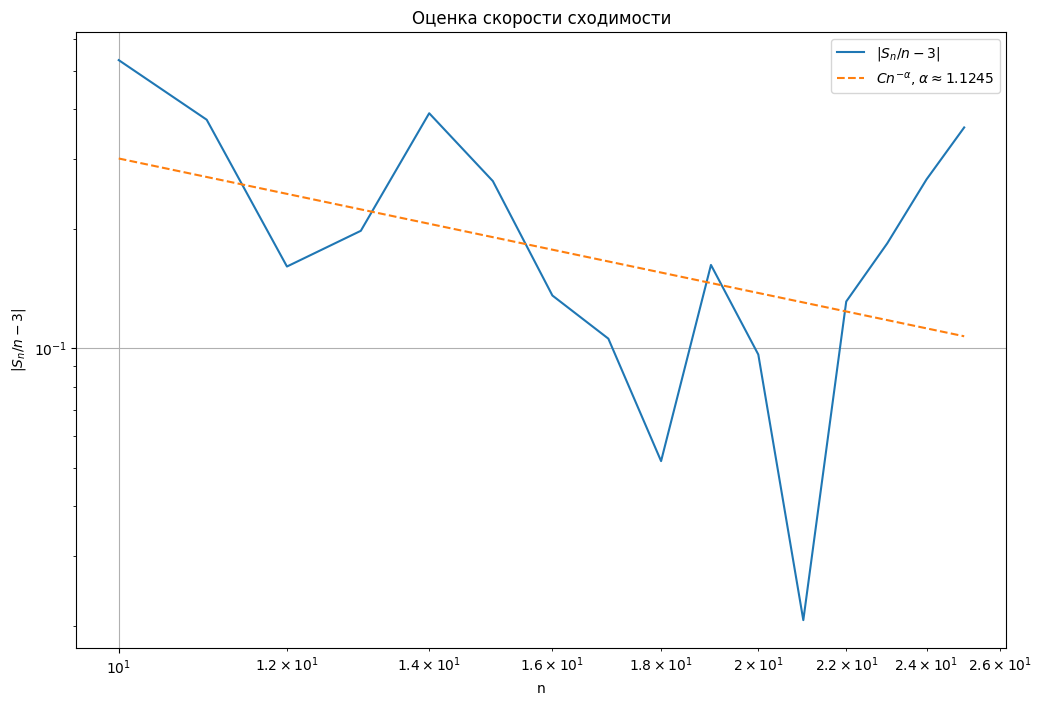

alpha ≈ 1.1245
C ≈ 4.0014
Размер выборки = 50


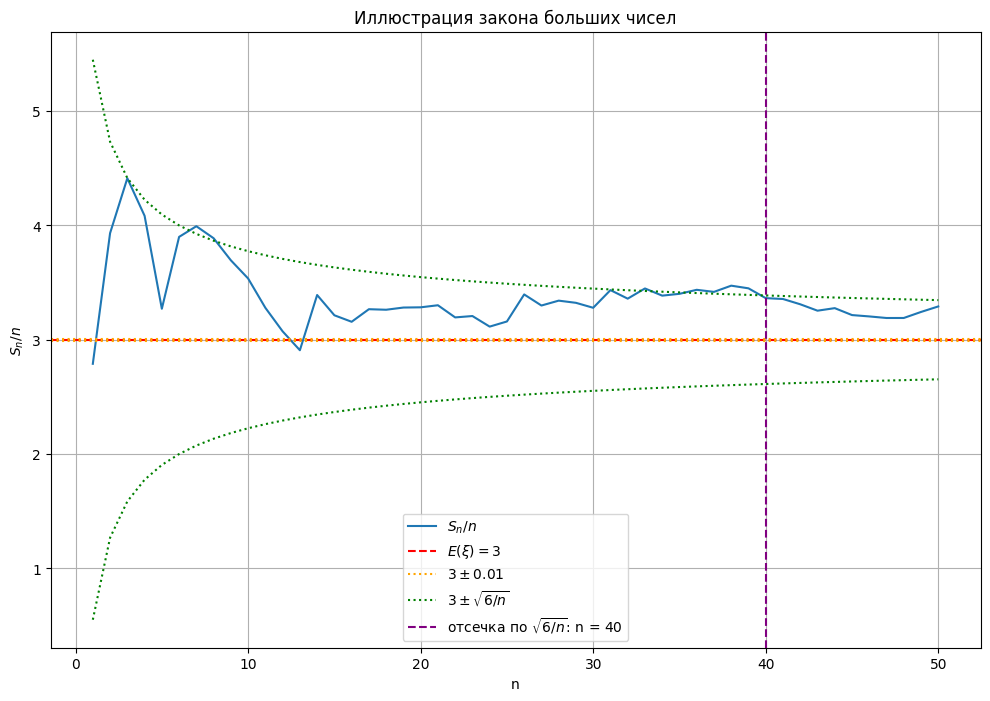

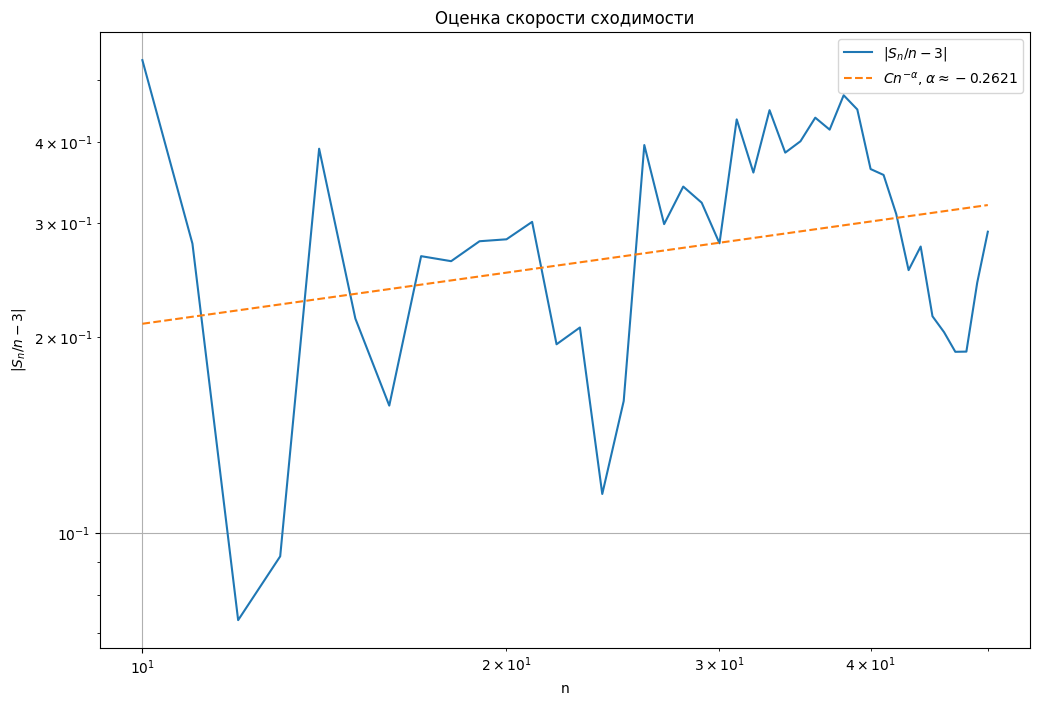

alpha ≈ -0.2621
C ≈ 0.1148
Размер выборки = 100


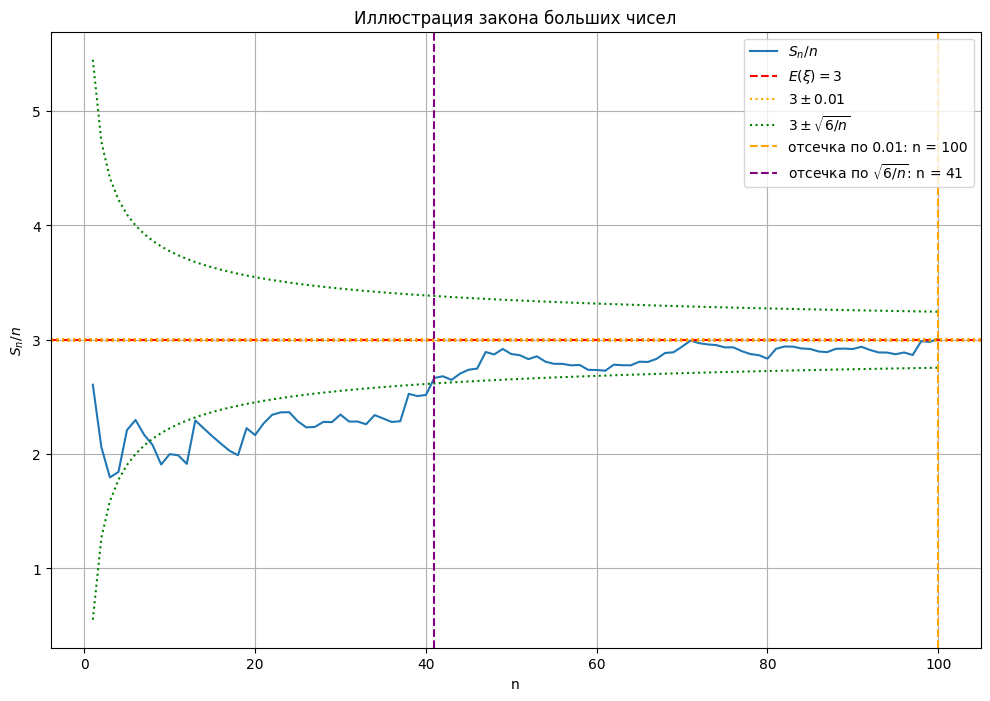

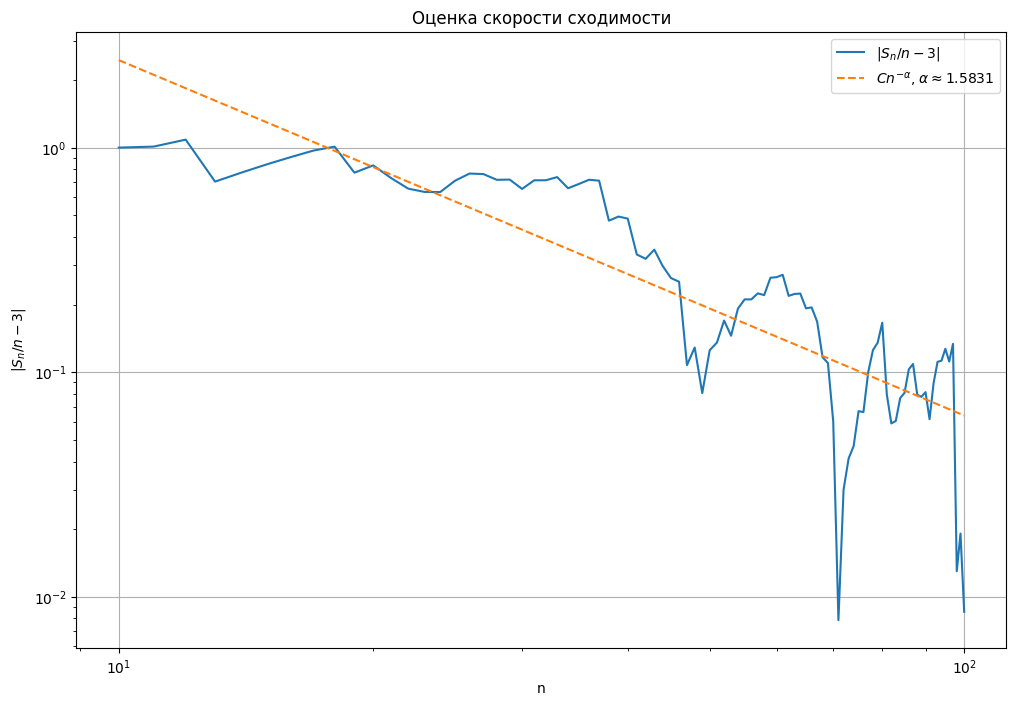

alpha ≈ 1.5831
C ≈ 93.9906
Размер выборки = 200


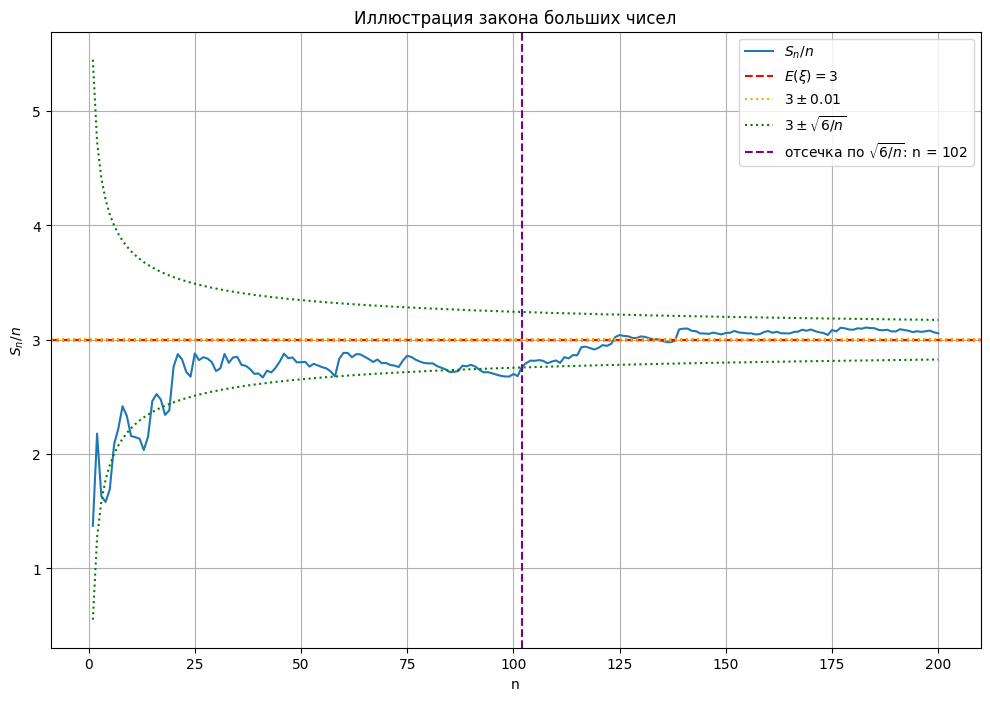

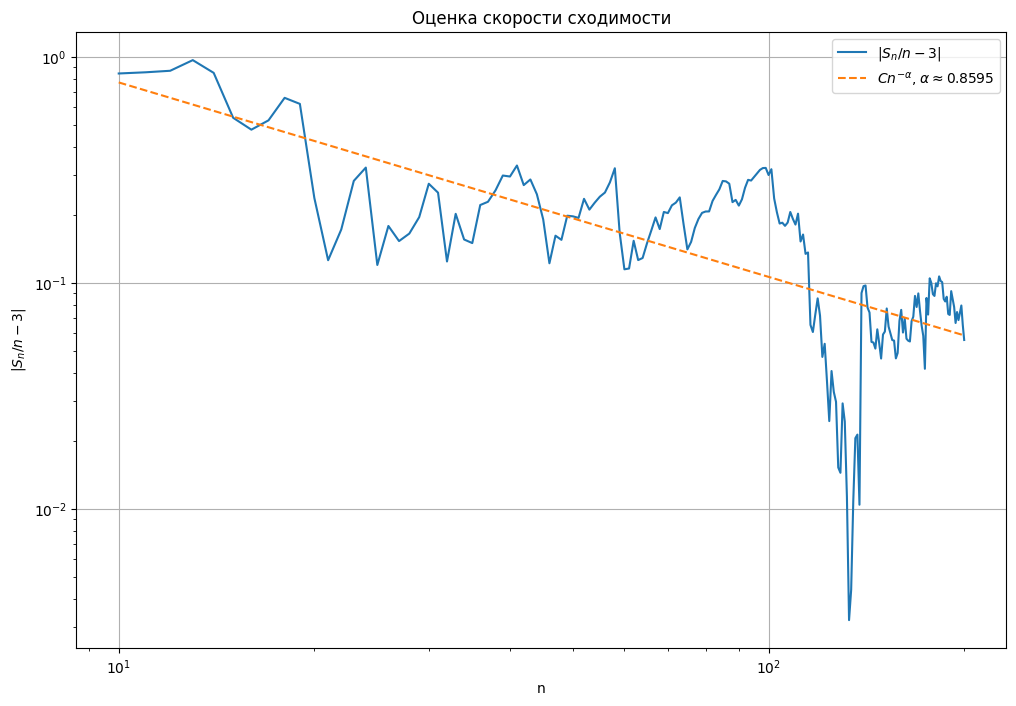

alpha ≈ 0.8595
C ≈ 5.5660
Размер выборки = 400


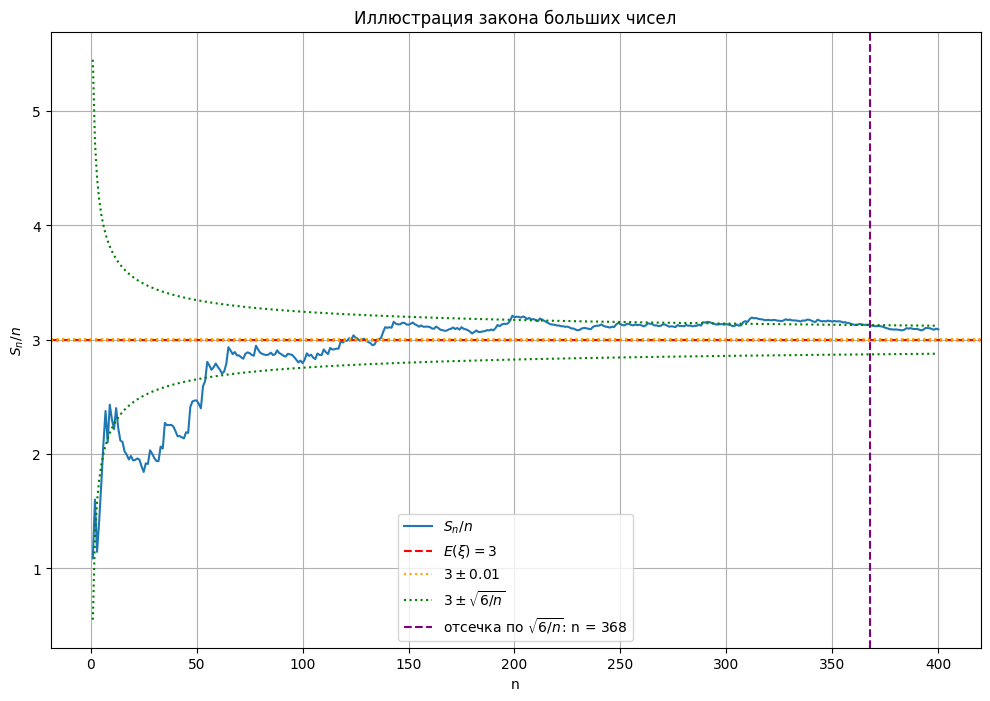

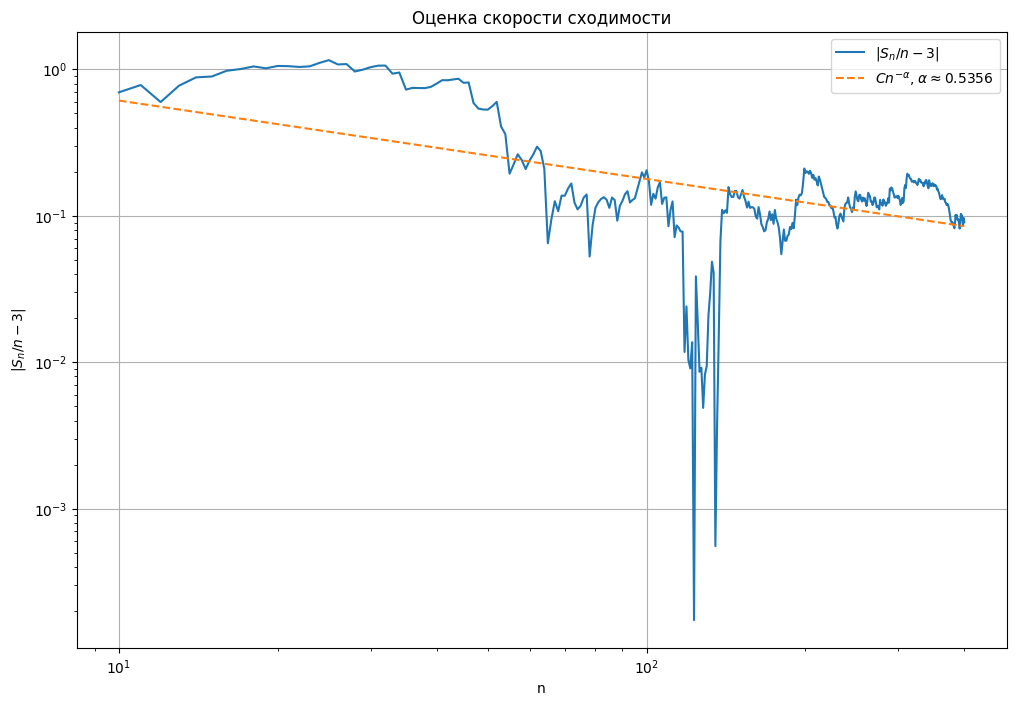

alpha ≈ 0.5356
C ≈ 2.1031
Размер выборки = 800


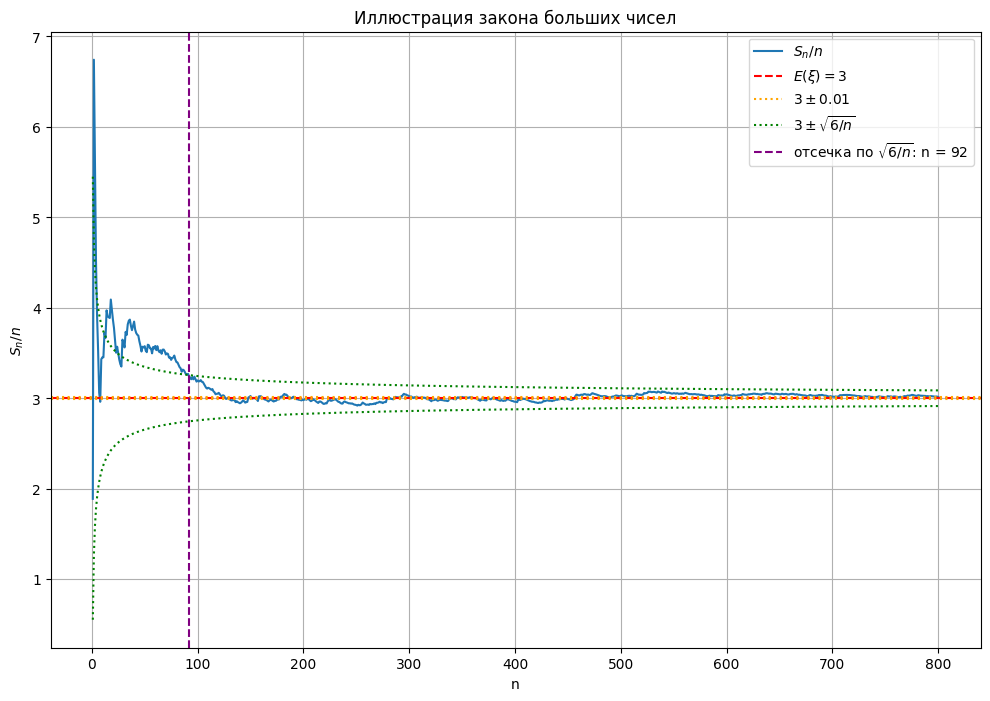

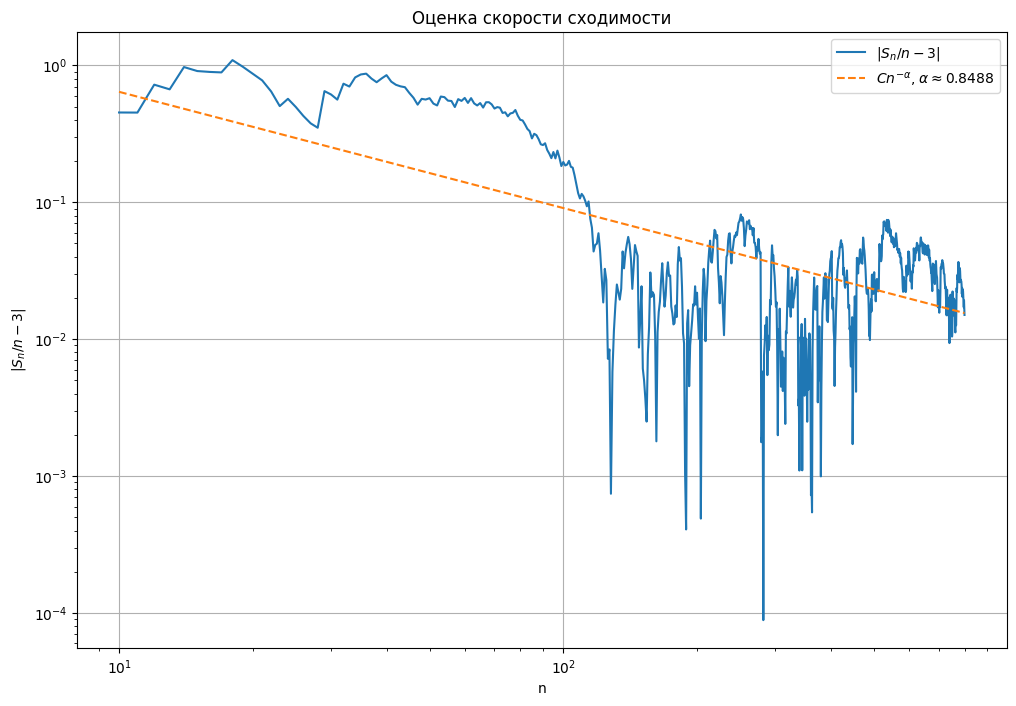

alpha ≈ 0.8488
C ≈ 4.5208
Размер выборки = 1600


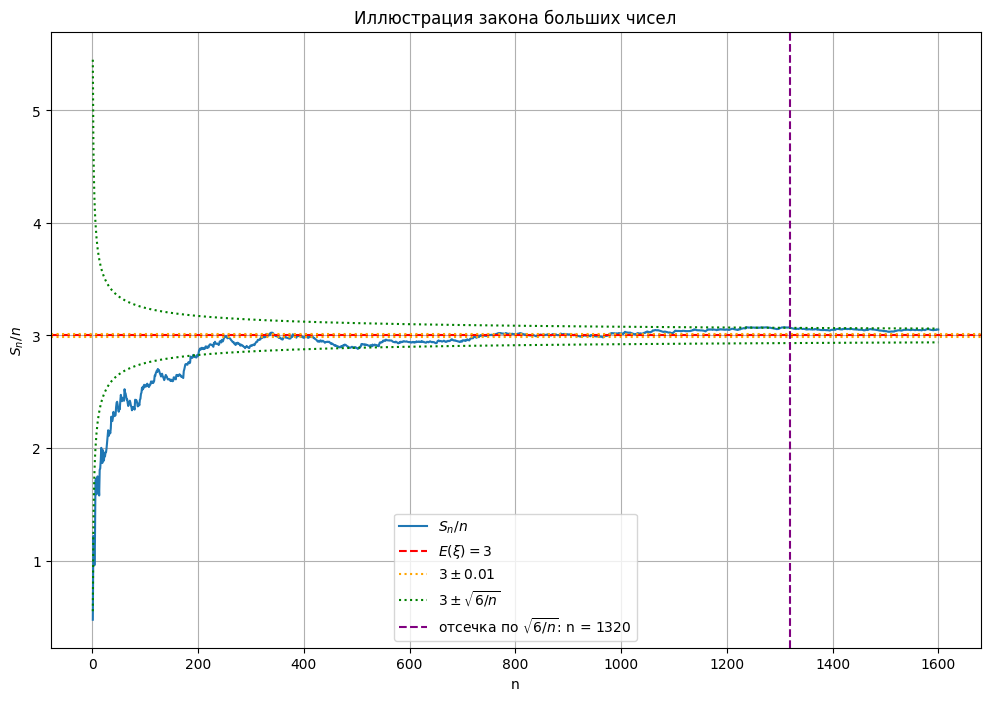

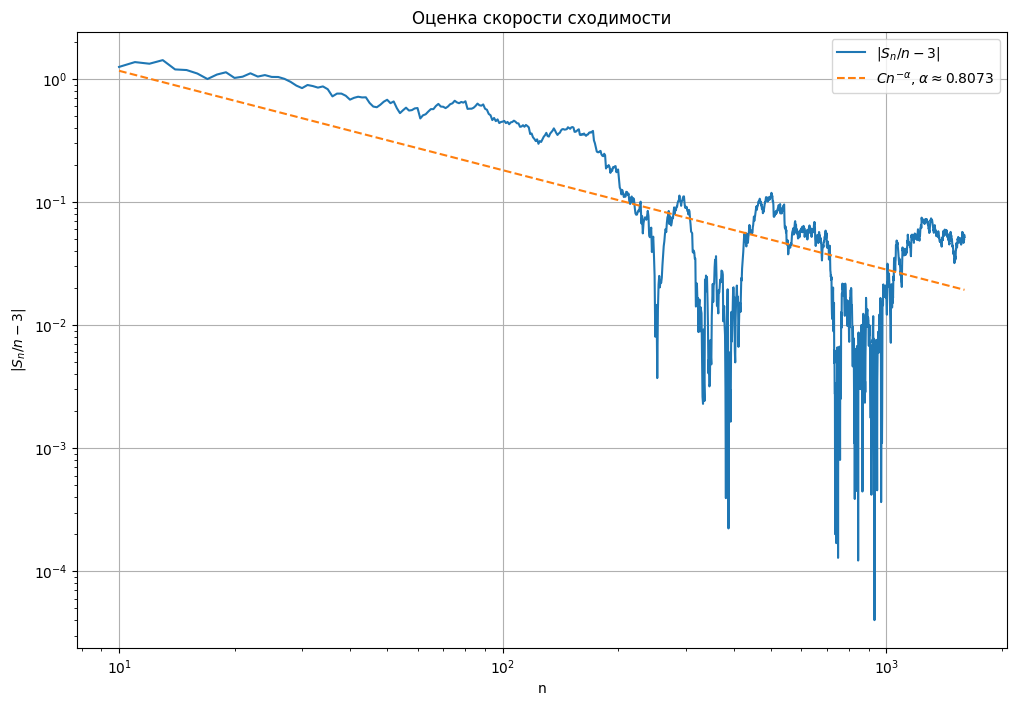

alpha ≈ 0.8073
C ≈ 7.4728
Размер выборки = 3200


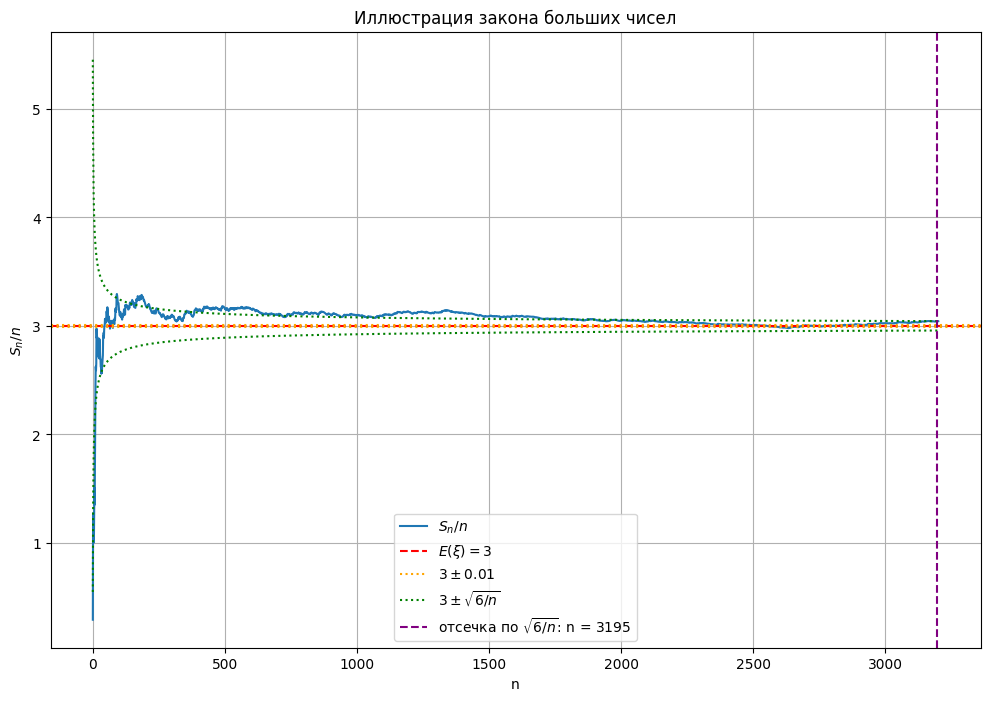

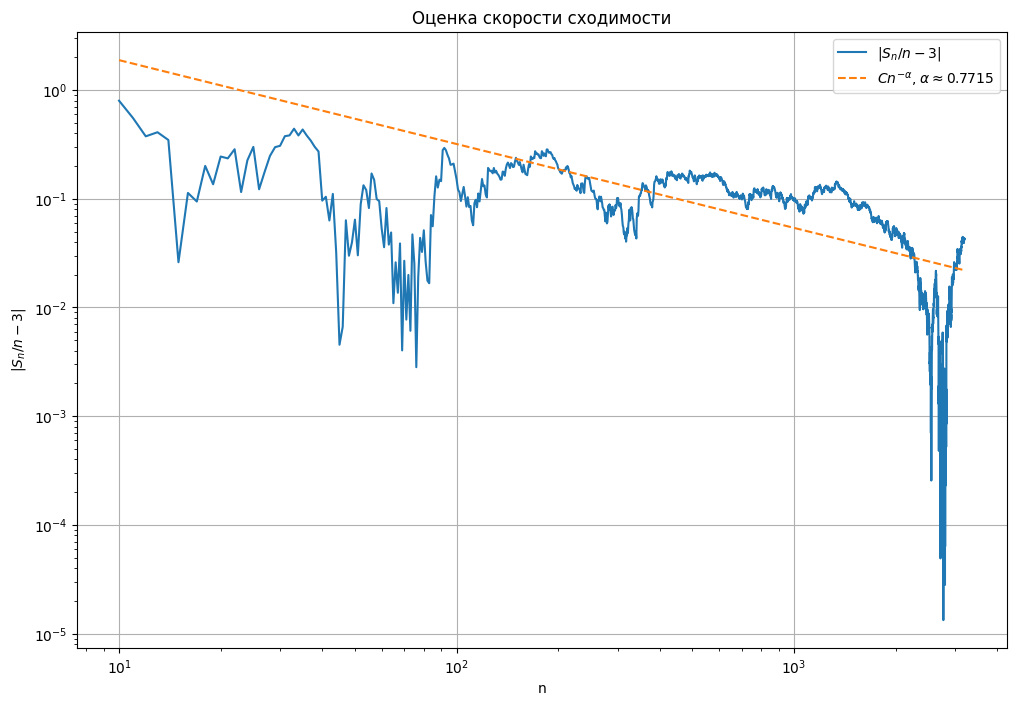

alpha ≈ 0.7715
C ≈ 11.1345
Размер выборки = 6400


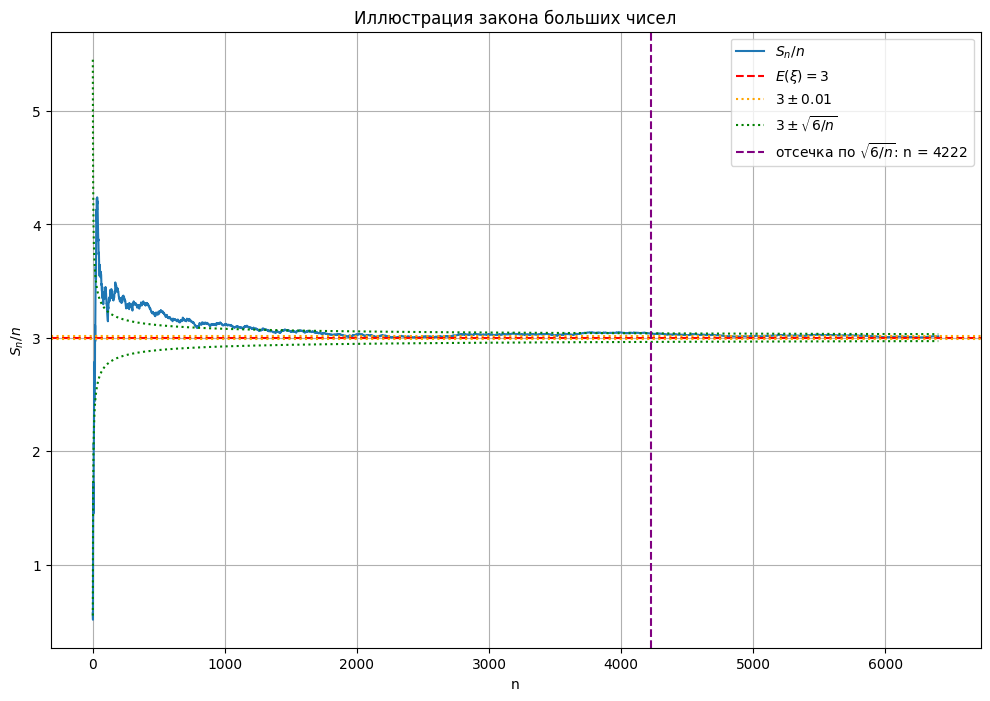

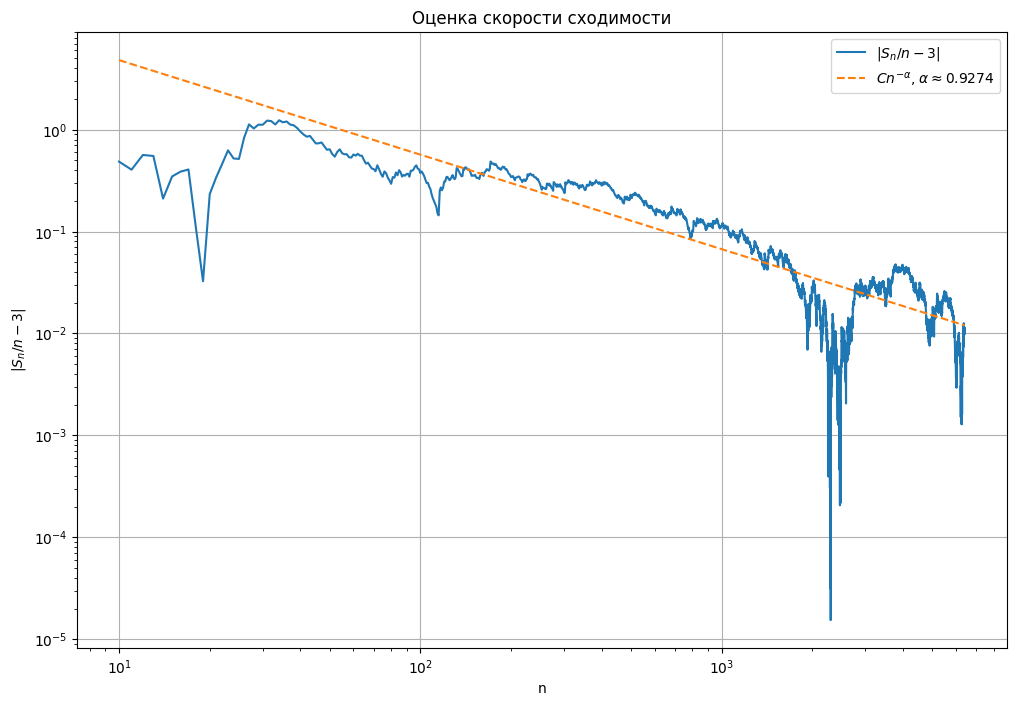

alpha ≈ 0.9274
C ≈ 40.7206
Размер выборки = 12800


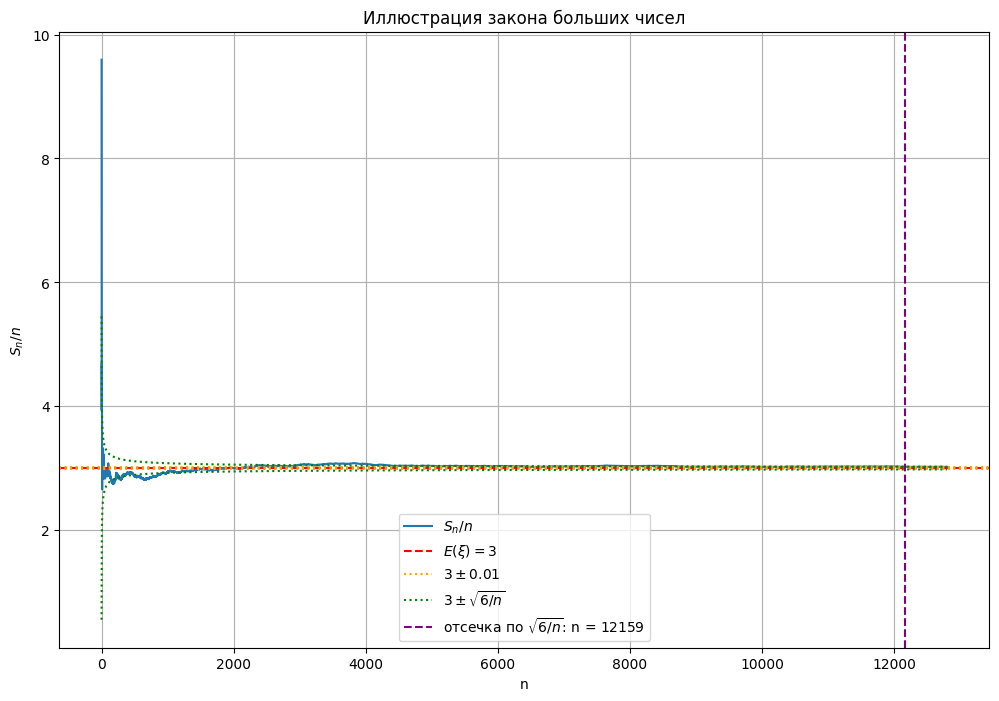

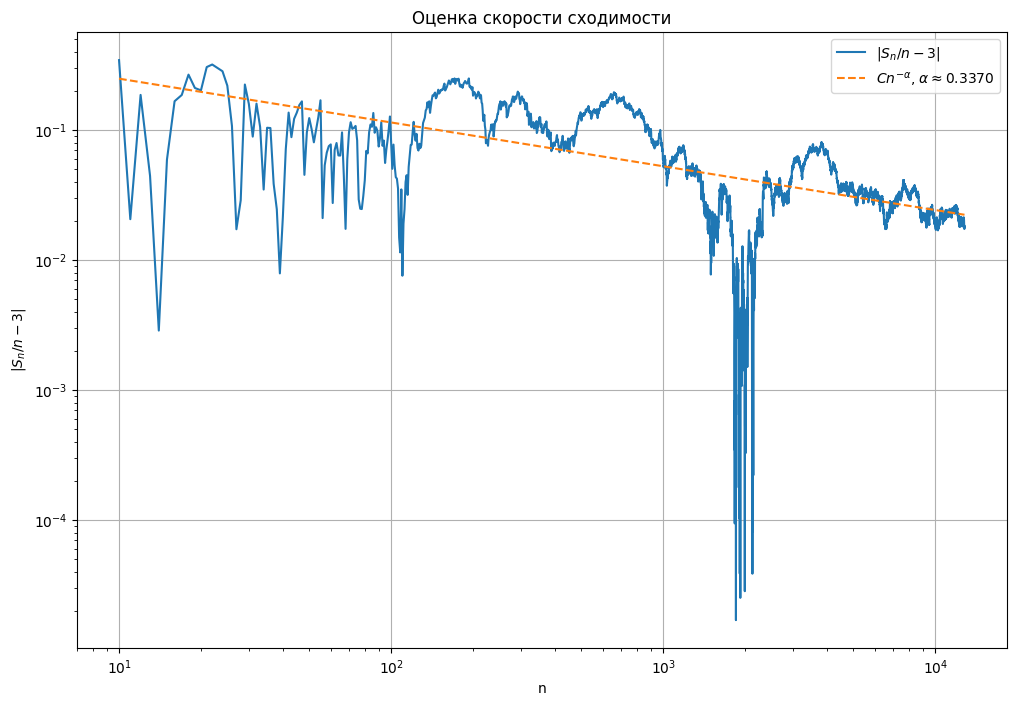

alpha ≈ 0.3370
C ≈ 0.5404
Размер выборки = 25600


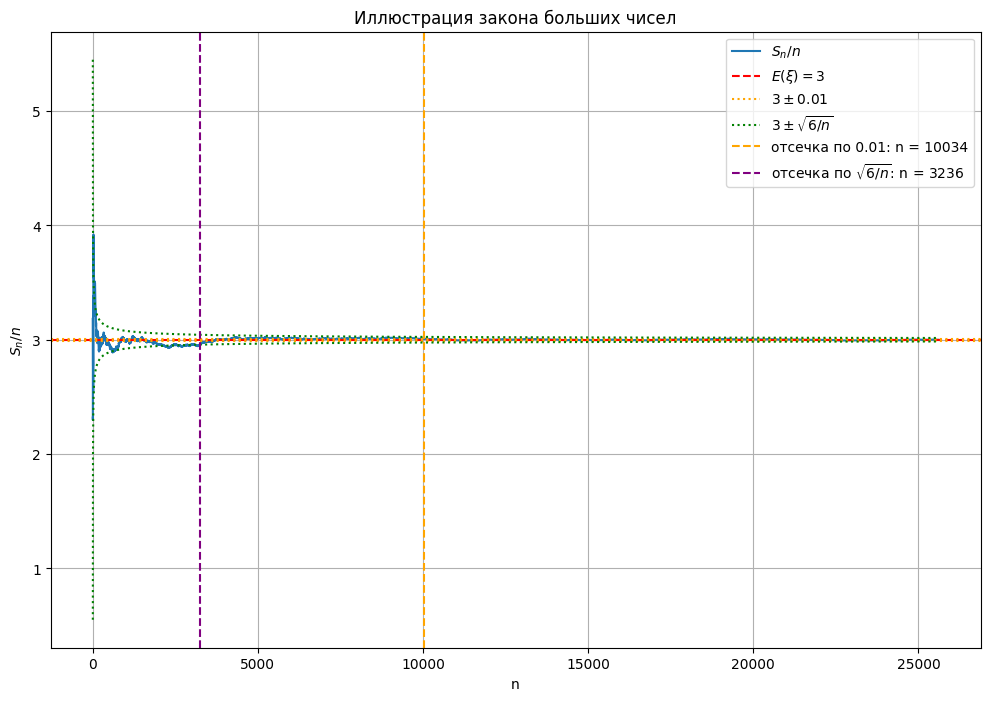

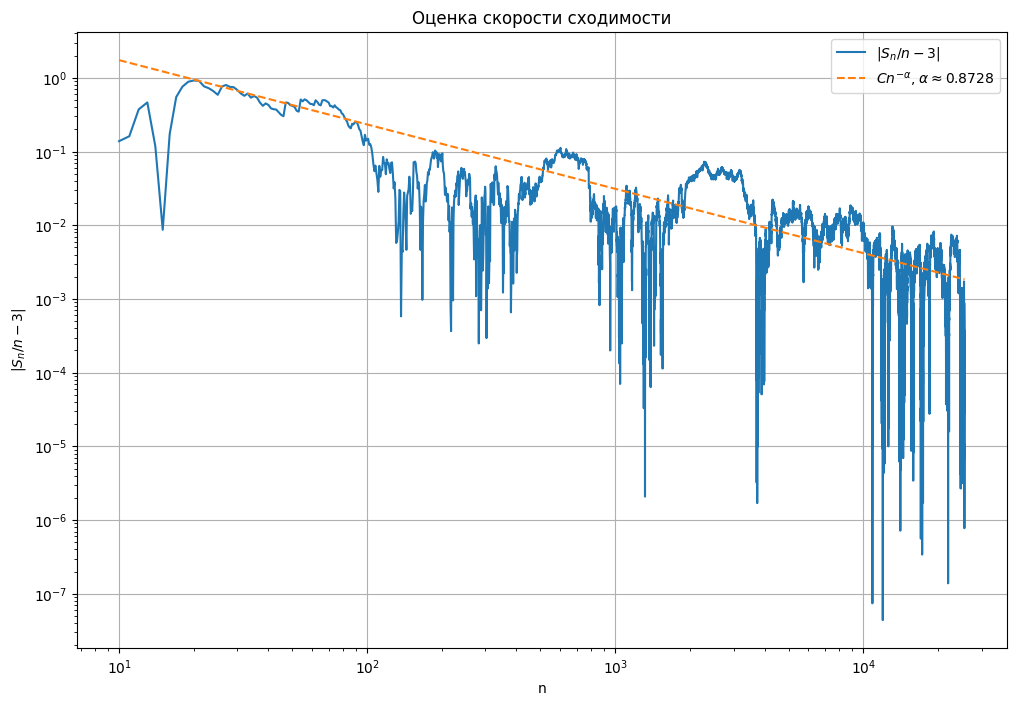

alpha ≈ 0.8728
C ≈ 12.9692
Размер выборки = 51200


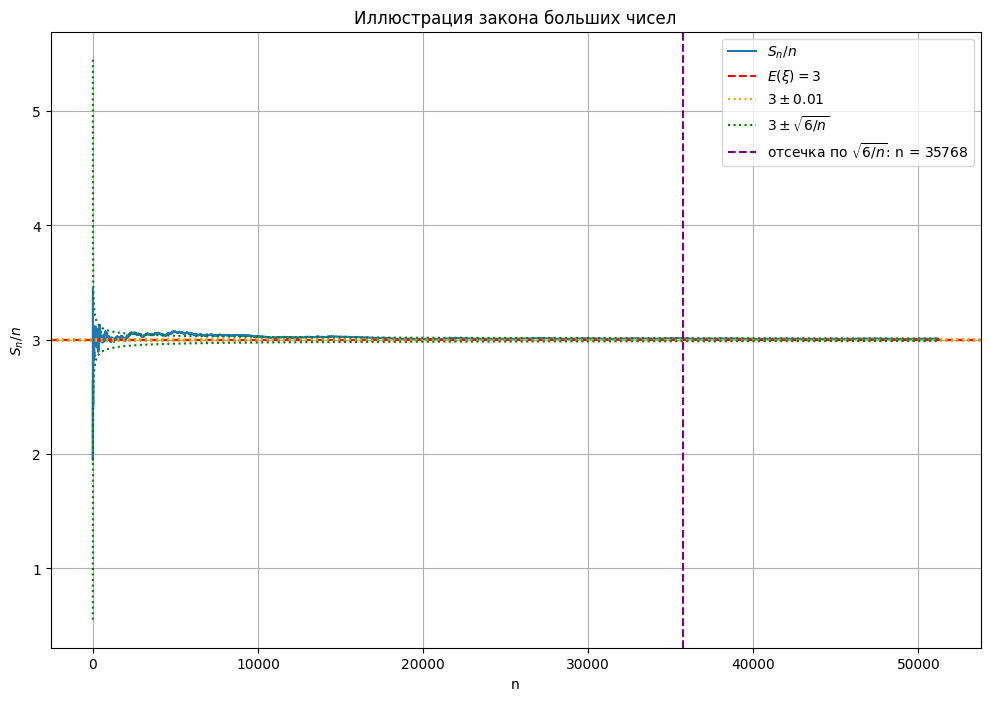

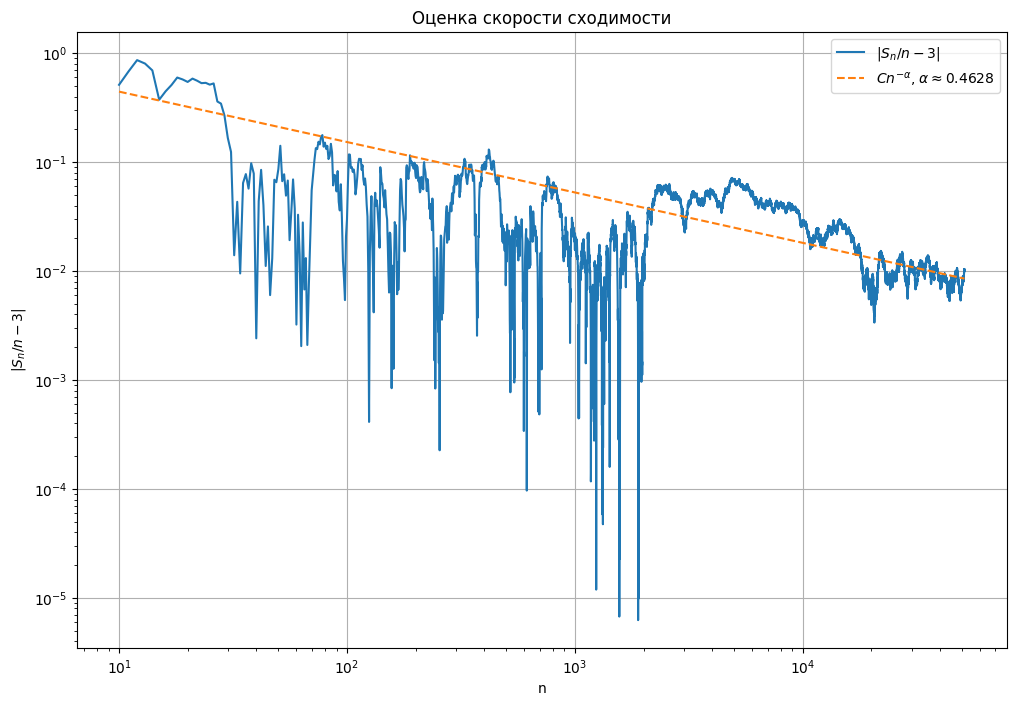

alpha ≈ 0.4628
C ≈ 1.2898
Размер выборки = 102400


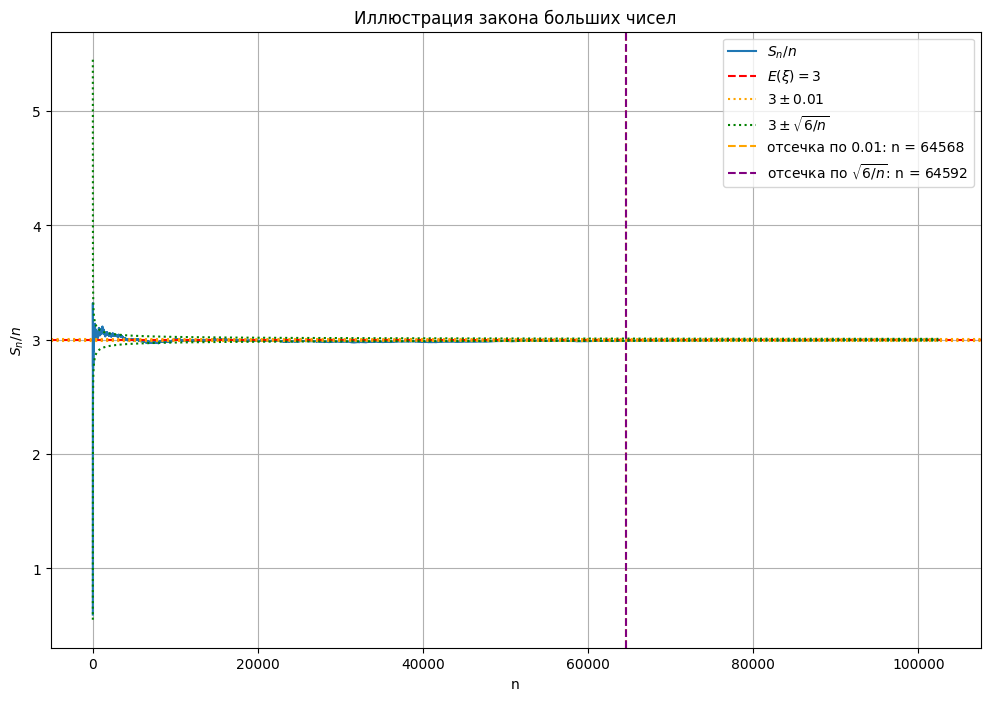

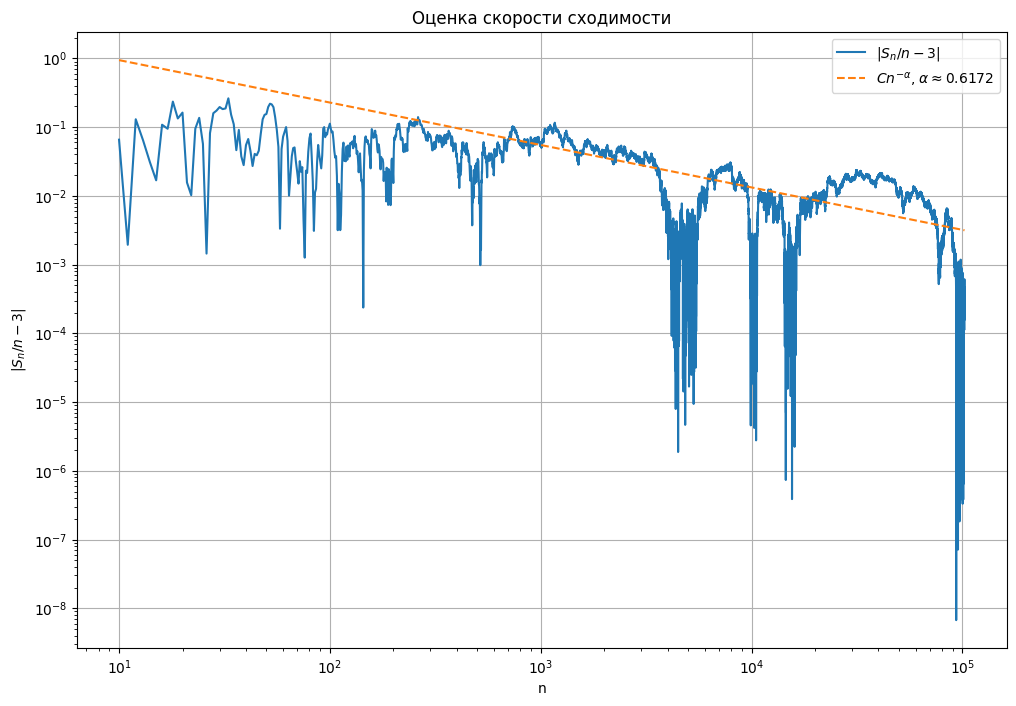

alpha ≈ 0.6172
C ≈ 3.9098
Размер выборки = 204800


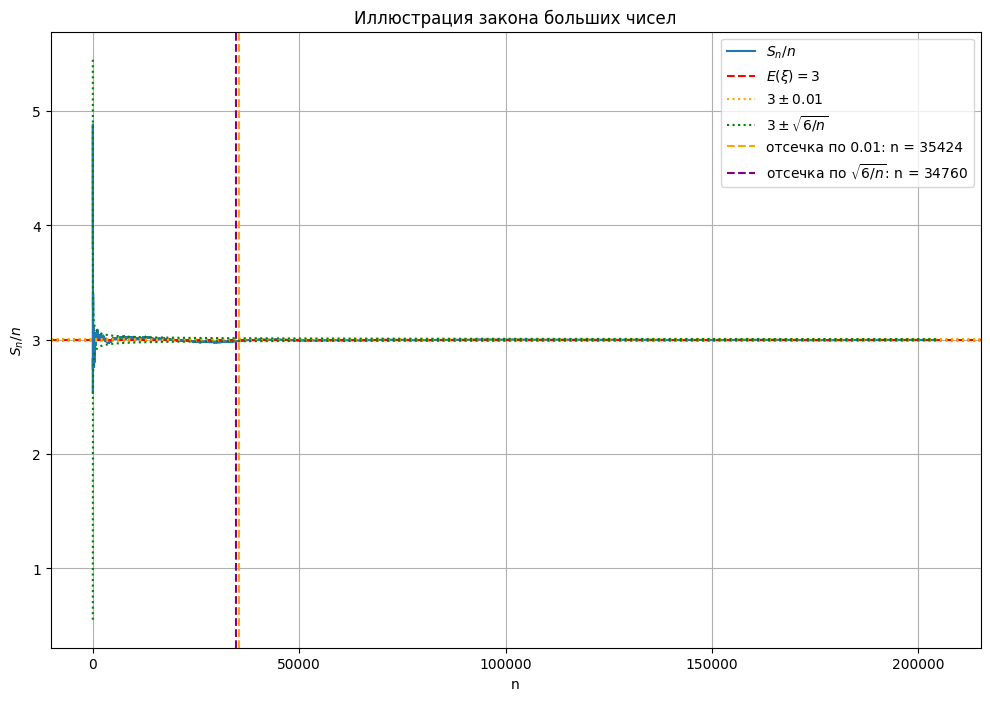

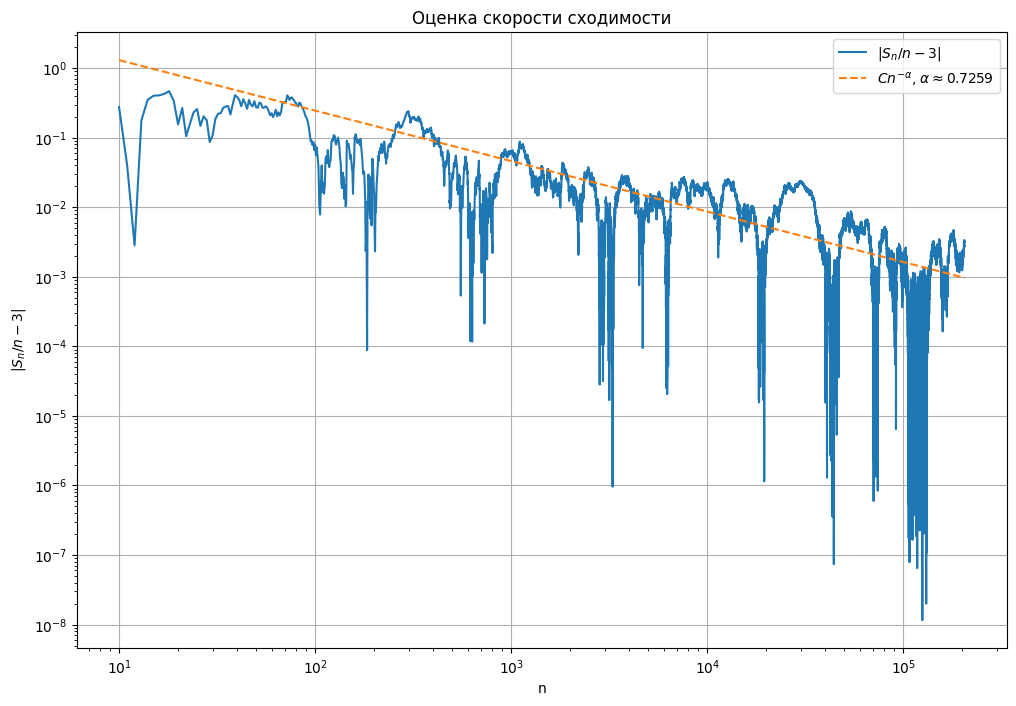

alpha ≈ 0.7259
C ≈ 6.9375
Размер выборки = 409600


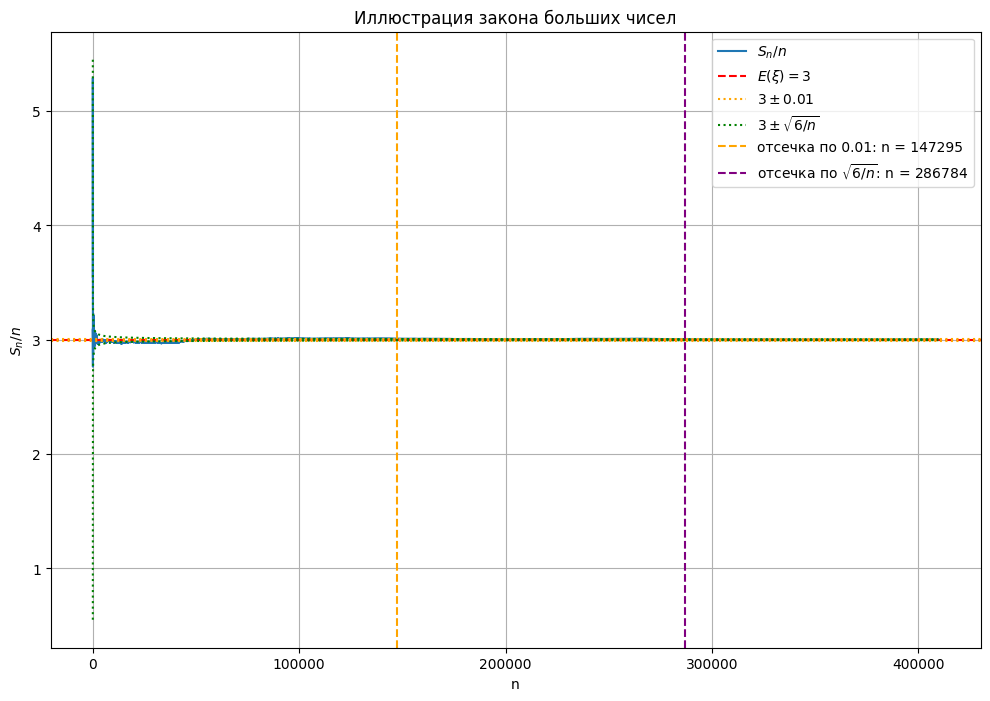

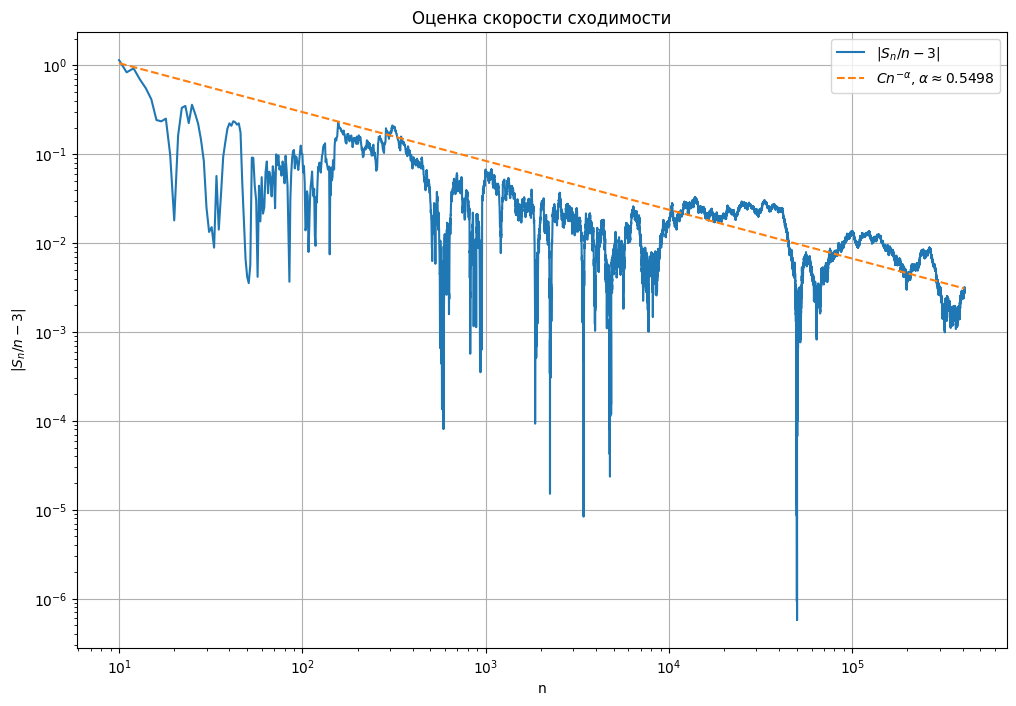

alpha ≈ 0.5498
C ≈ 3.7595
Размер выборки = 1000000


c:\Users\Cyber Kanojo\Desktop\programming\Mathematical_statistics\Mathematical_statistics\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


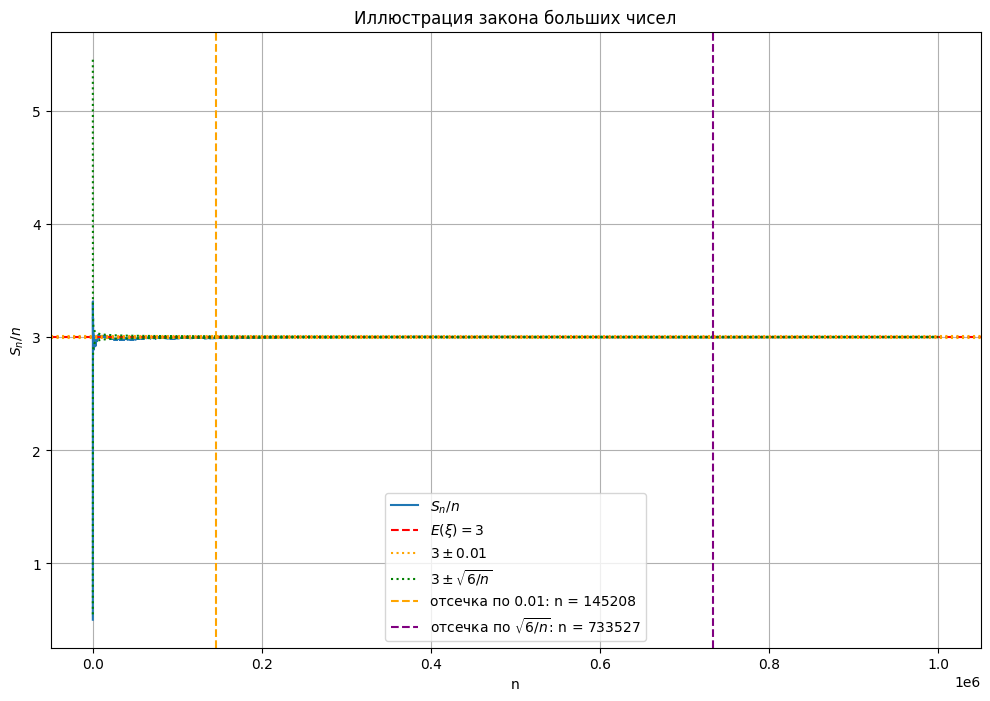

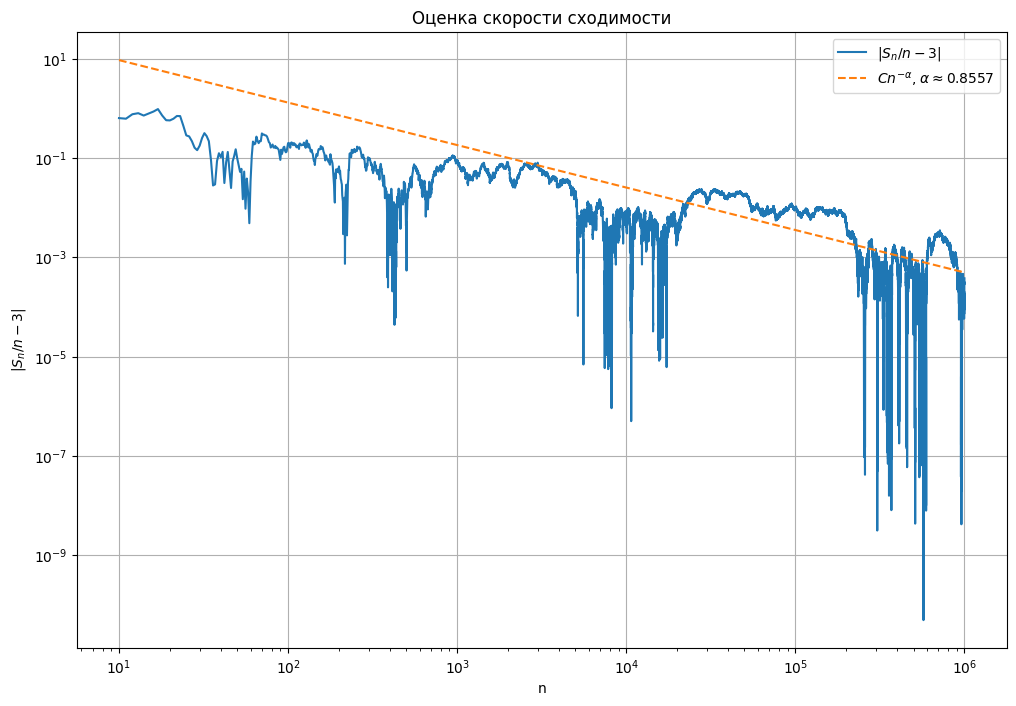

alpha ≈ 0.8557
C ≈ 67.6054
Размер выборки = 2000000


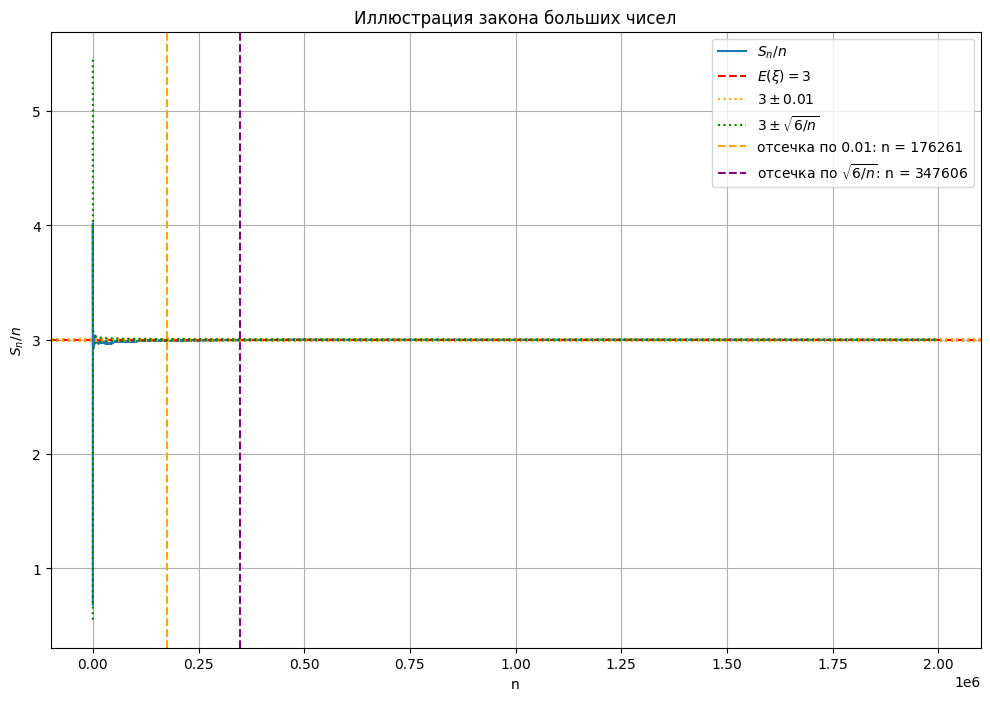

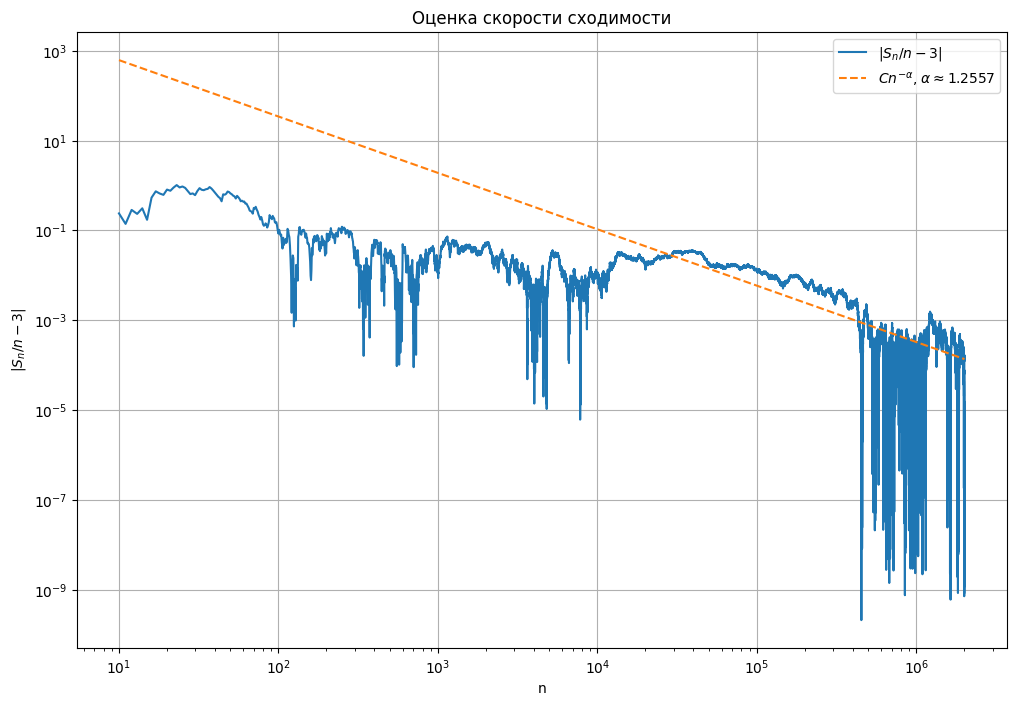

alpha ≈ 1.2557
C ≈ 11116.4357
Размер выборки = 3000000


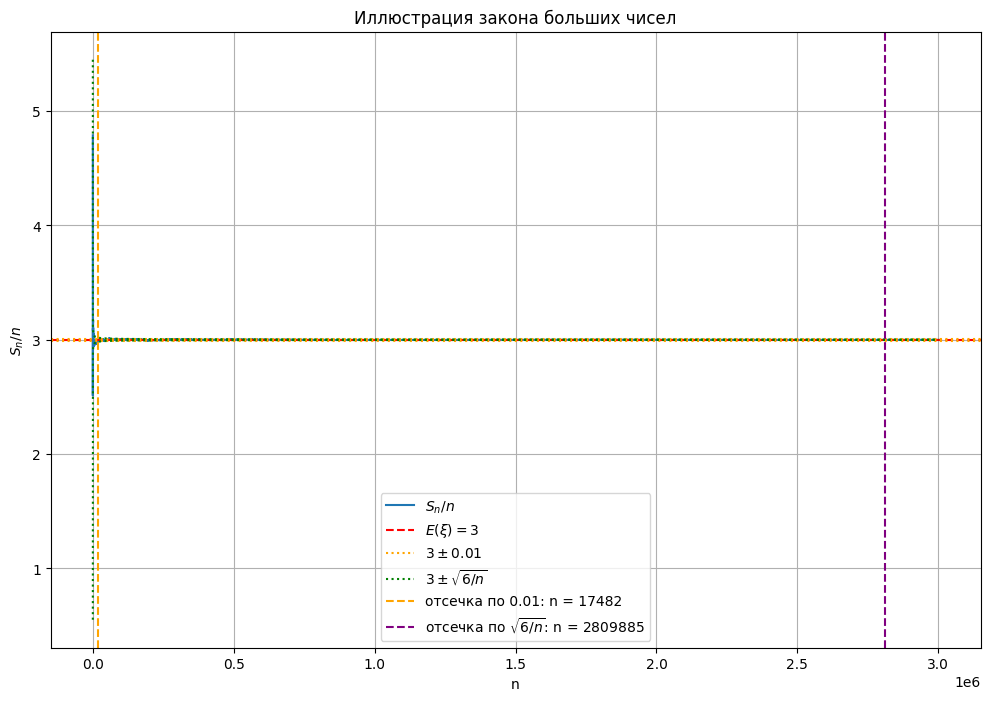

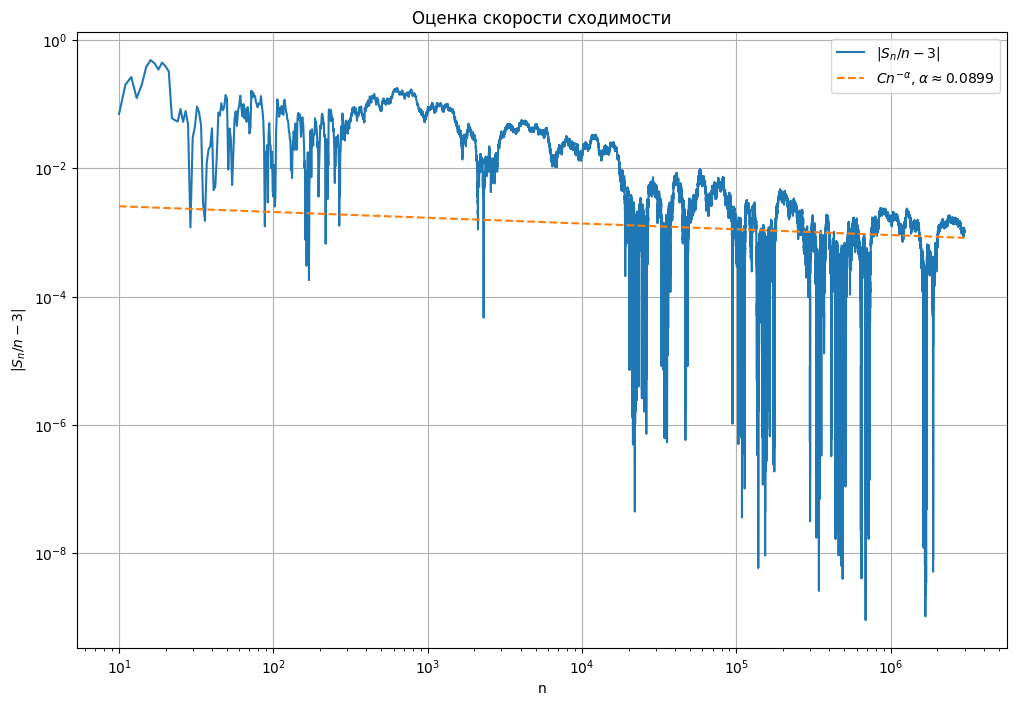

alpha ≈ 0.0899
C ≈ 0.0032
Размер выборки = 4000000


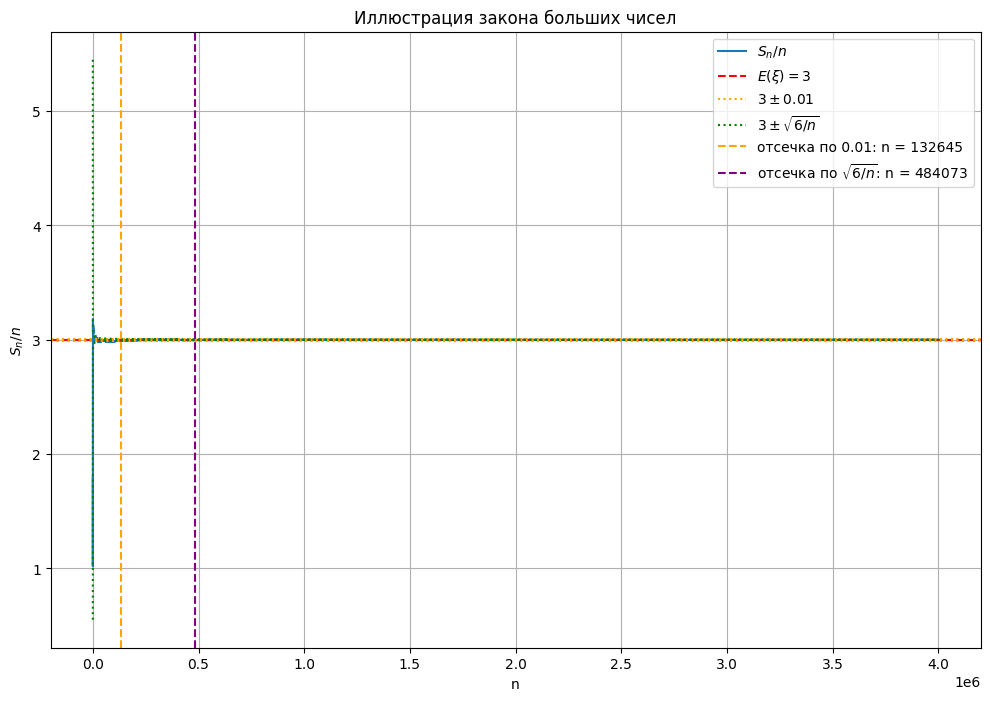

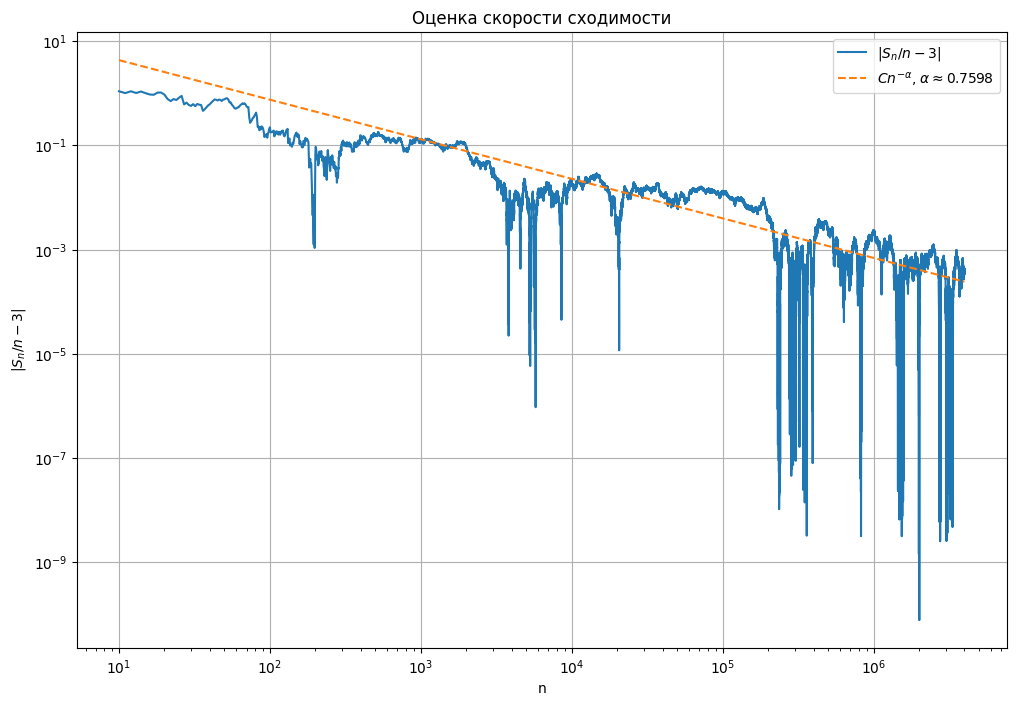

alpha ≈ 0.7598
C ≈ 25.0842
Размер выборки = 5000000


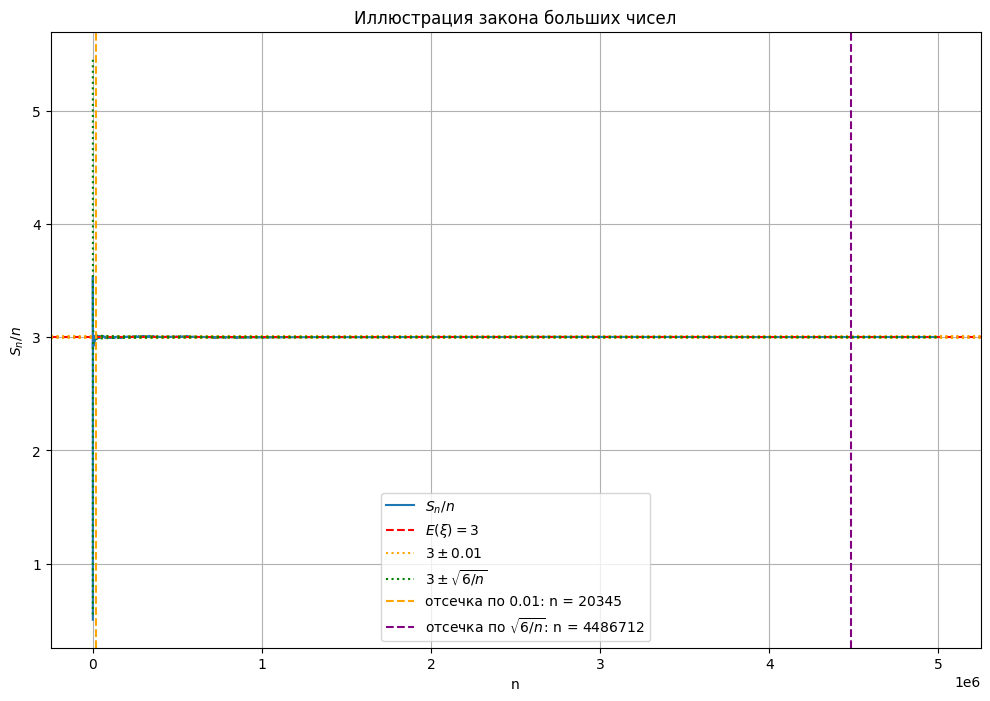

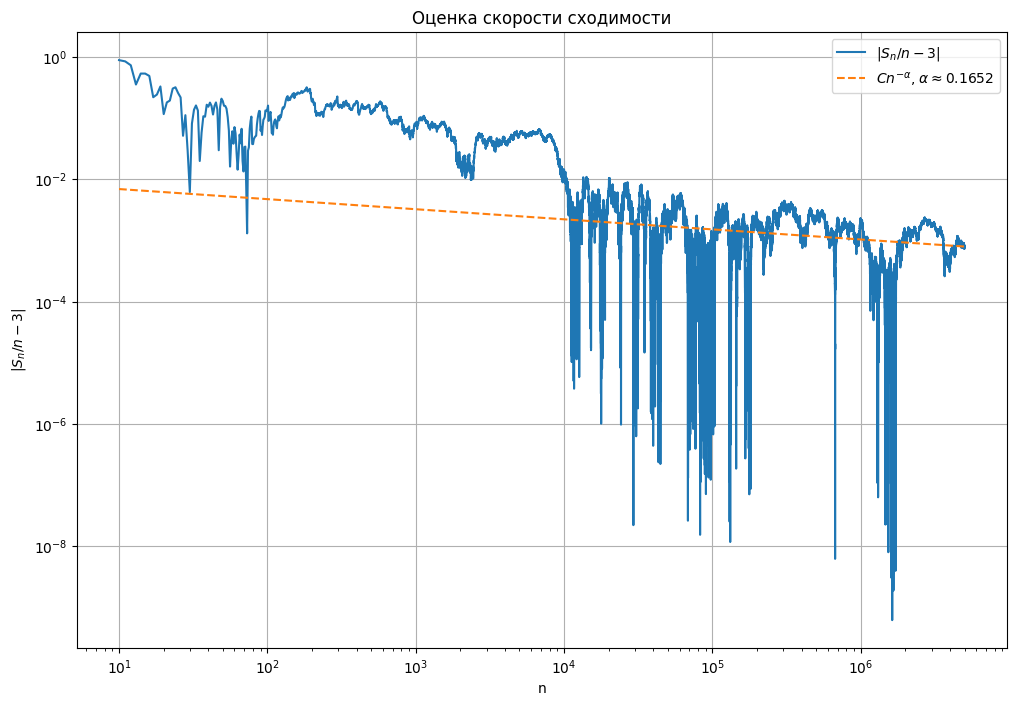

alpha ≈ 0.1652
C ≈ 0.0102
Размер выборки = 6000000


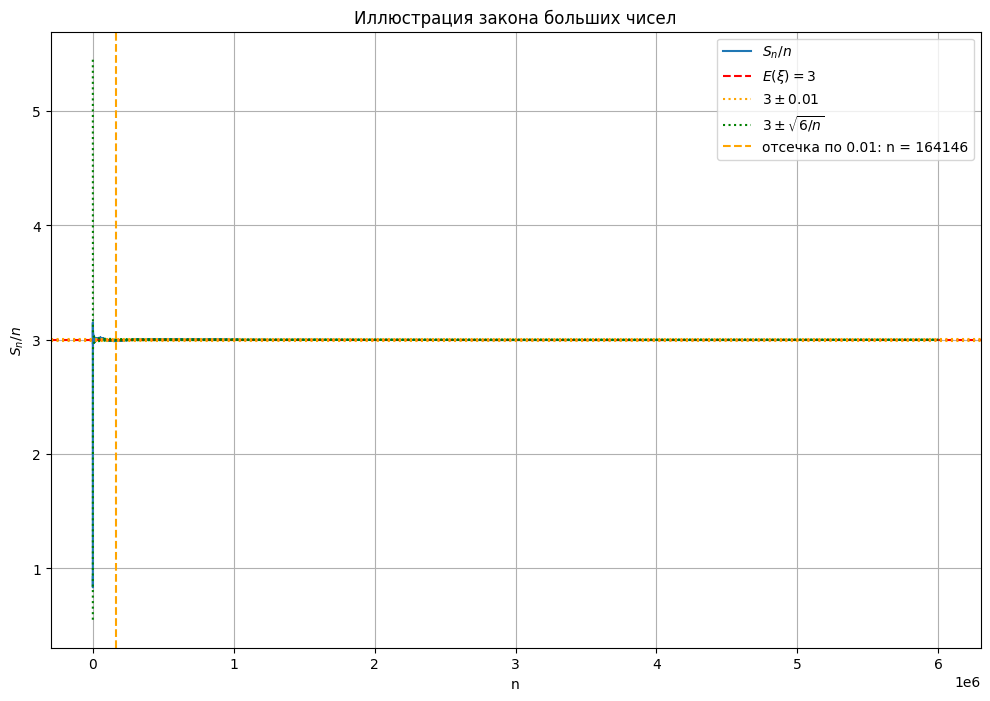

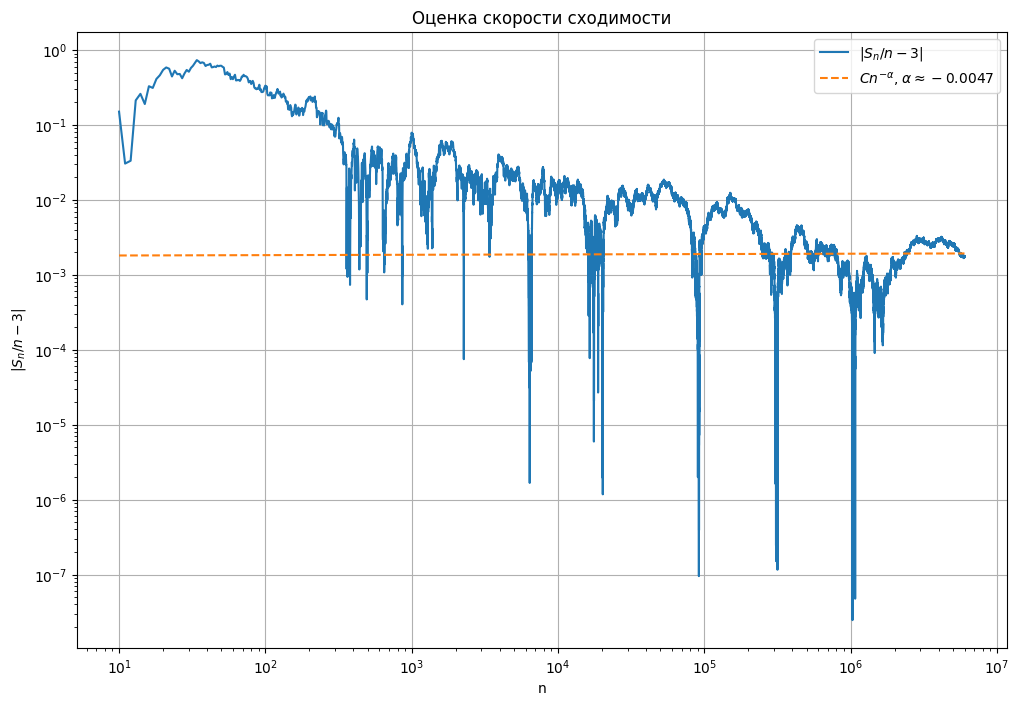

alpha ≈ -0.0047
C ≈ 0.0018
Размер выборки = 7000000


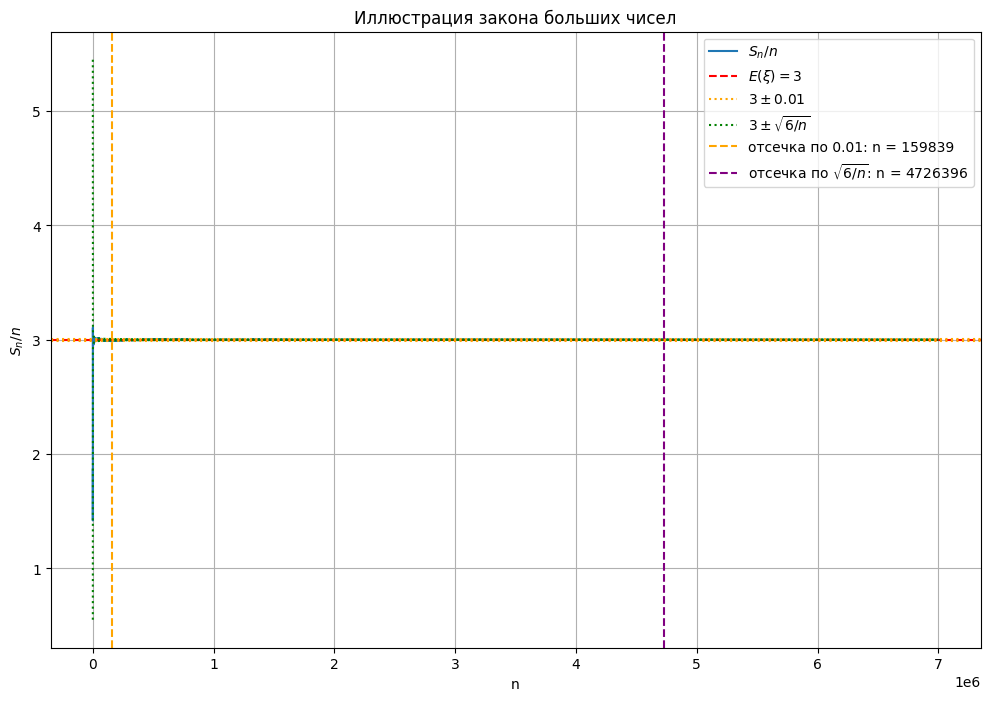

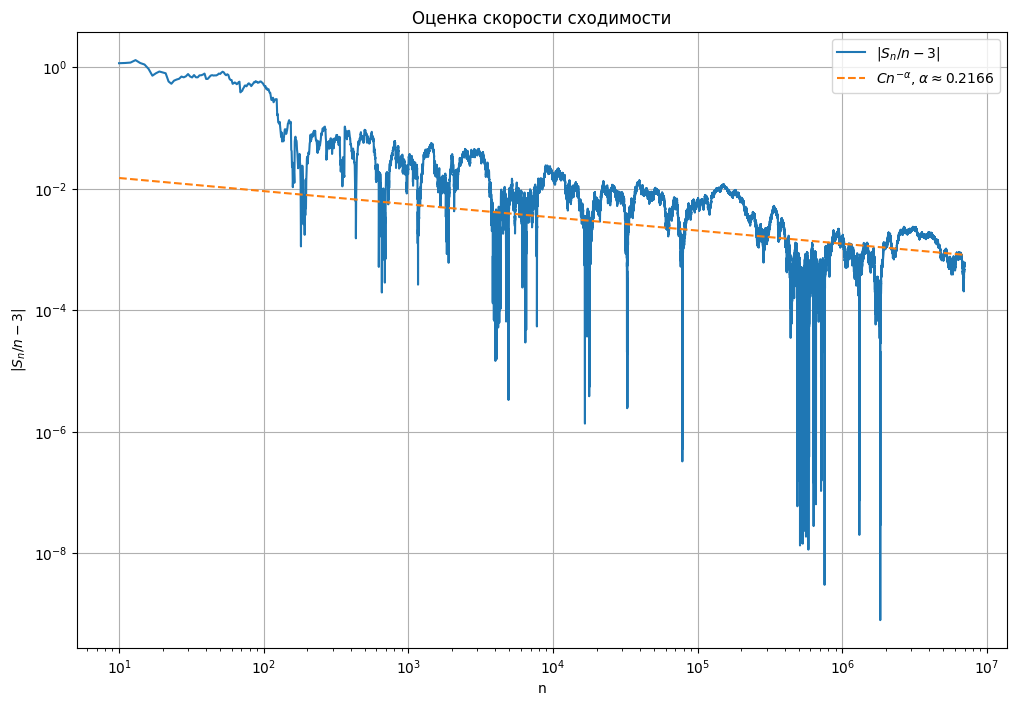

alpha ≈ 0.2166
C ≈ 0.0249
Размер выборки = 8000000


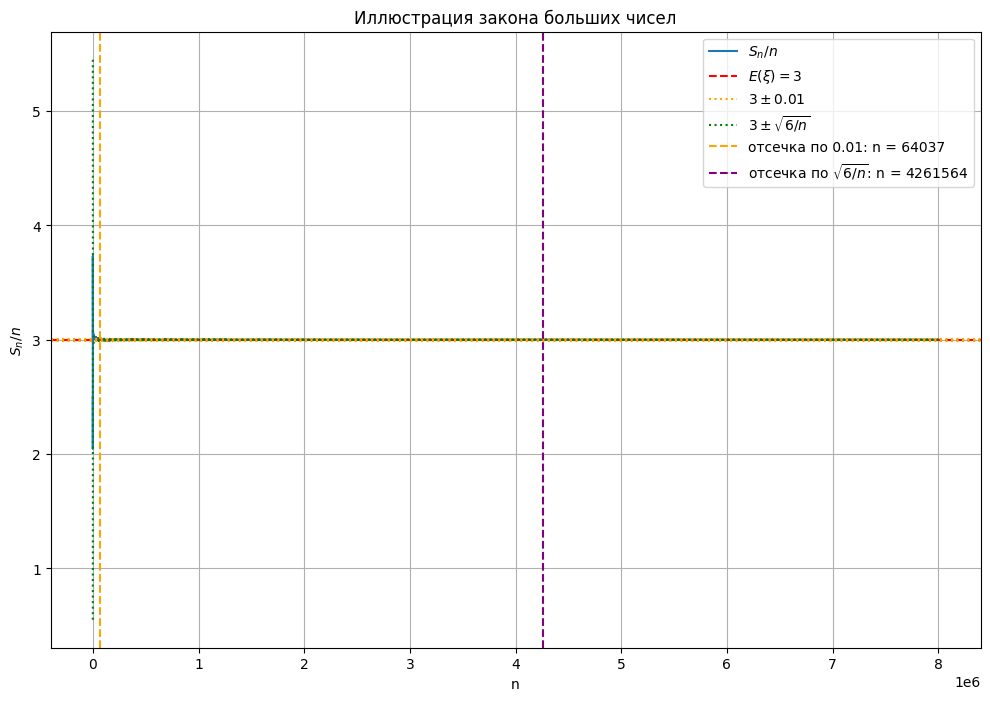

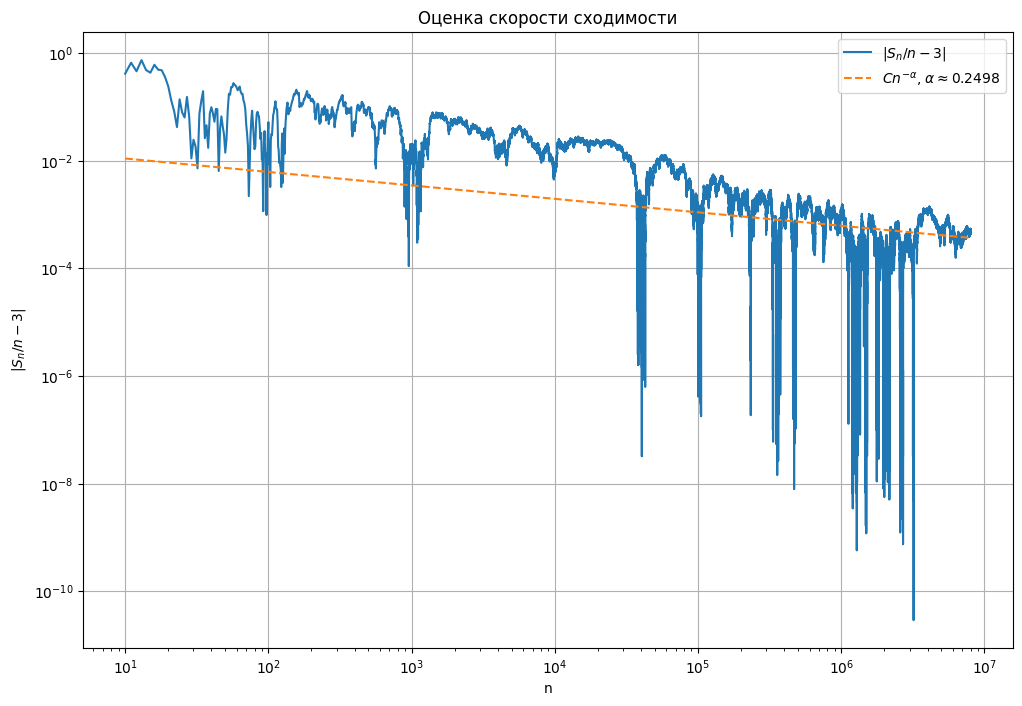

alpha ≈ 0.2498
C ≈ 0.0194
Размер выборки = 9000000


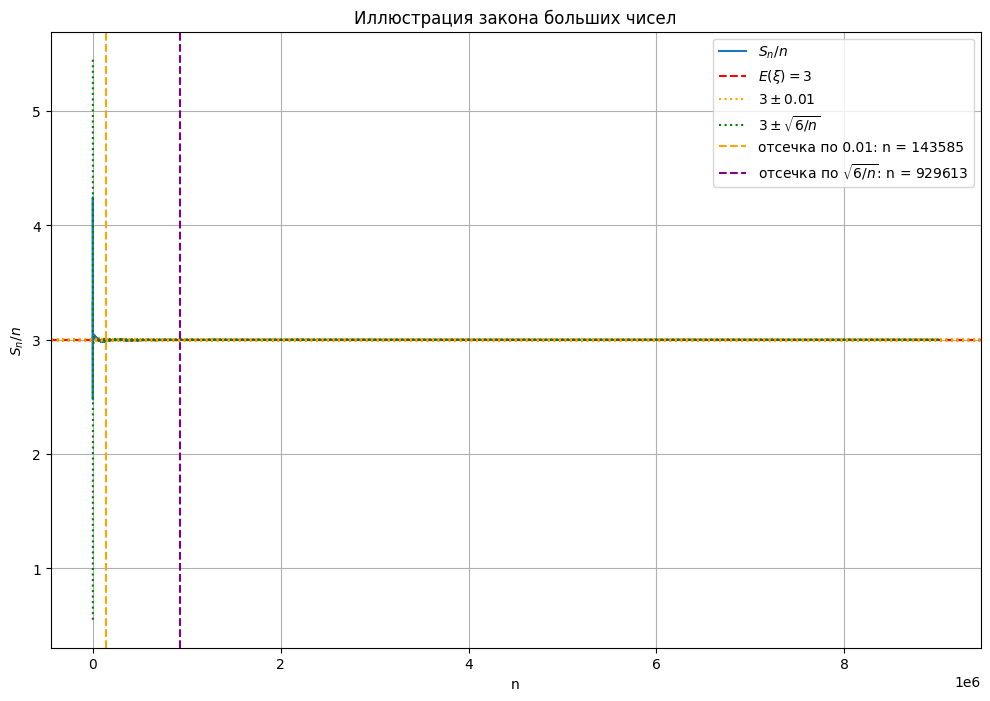

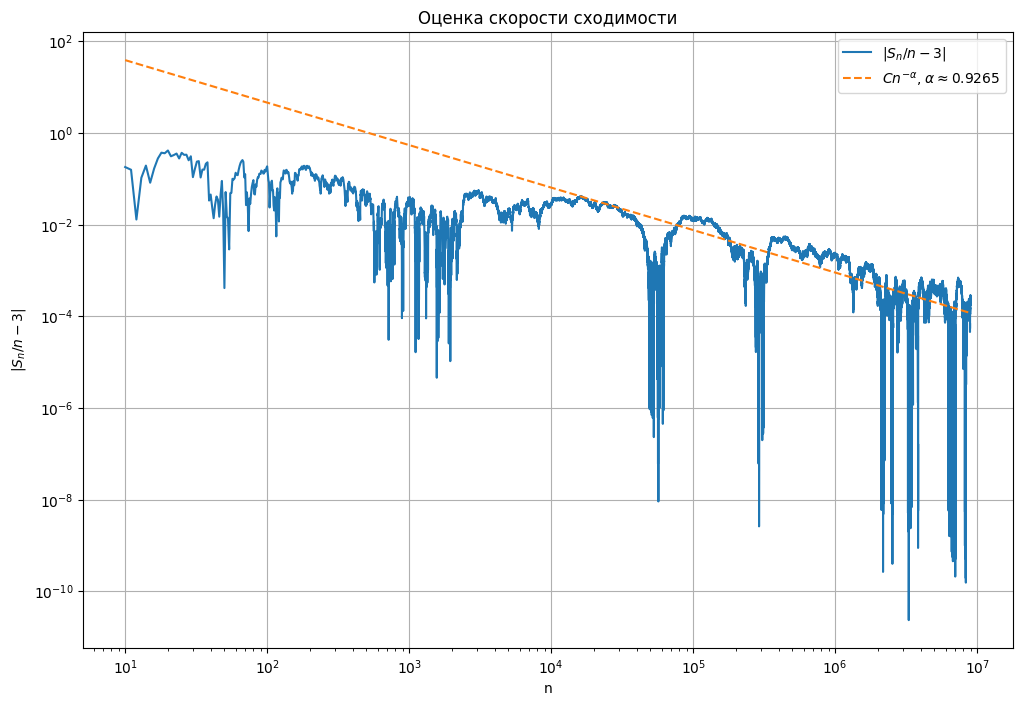

alpha ≈ 0.9265
C ≈ 325.0265


In [8]:
counter = 25
alpha_list = []
n_list = []
while (counter < 500_000):
    sample_mean = sample(N=counter)
    illustration(sample_mean)
    alpha_list.append(plot_estimate_rate(sample_mean))
    n_list.append(counter)
    counter *= 2

second_counter = 1_000_000
while (second_counter < 10_000_000):
    sample_mean = sample(N=second_counter)
    illustration(sample_mean)
    alpha_list.append(plot_estimate_rate(sample_mean))
    n_list.append(second_counter)
    second_counter += 1_000_000



Посмотрим на значение $\alpha$ с увеличением выборки.

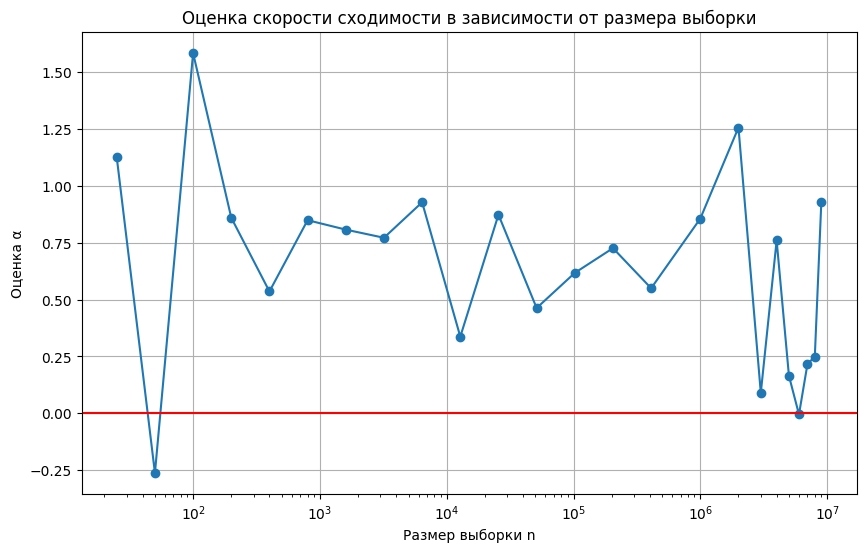

In [9]:
plt.figure(figsize=(10,6))

plt.plot(n_list, alpha_list, marker='o')
plt.axhline(0, color='red')

plt.xscale("log")

plt.xlabel("Размер выборки n")
plt.ylabel("Оценка α")
plt.title("Оценка скорости сходимости в зависимости от размера выборки")

plt.grid()
plt.show()

Кажется, что подобный подход не вполне информативен: мы видим, что в целом да, всё плюс минус сходится к математическому ожиданию, при этом, если при маленьких значениях константная отсечка срабатывала не всегда, то при больших уже наоборот - не всегда срабатывает динамическая.

При этом значение параметра $\alpha$ с увеличением выборки не сильно устаканивается, а колеблется. Нужно подойти к вопросу немного иначе.

Ответим на следующий вопрос: Какой нужен размер выборки, чтобы с определенной вероятностью ошибка была не выше определенной $\epsilon$?

Положим: $\overline{X_n} = \frac{S_n}{n}$, тогда естественно было бы положить следующий критерий:  
$\mathbb{P}(|\overline{X_n} - 3| \leq \epsilon) \geq p$, где $\epsilon$ - желаемая точность, а $p$ - желаемая вероятность, т.е. параметры. 

Заметим то, что я не заметил на экзамене по теории вероятностей - возможность применить Центральную предельную теорему:

$\xi_1, \xi_2, ...$ - $iid$,   $\mathbb{E}(\xi_i) = 3, \  \mathbb{D}(\xi_i) = 6$, тогда для $\overline{X_n} = \frac{S_n}{n} = \frac{\xi_1 + \xi_2 + ...}{n} $ ЦПТ, которая: $\frac{S_n - \mathbb{E}(S_n)}{\sqrt{\mathbb{D}(S_n)}} \xrightarrow{d} \eta \sim N(0,1), \ n \rightarrow \infty$

$\Longrightarrow \frac{S_n - 3n}{\sqrt{6n}} = \frac{n(\frac{S_n}{n} - 3)}{\sqrt{6n}}$ $ = \frac{\overline{X_n} - 3}{\sqrt{\frac{6}{n}}} \xrightarrow{d} \eta \sim N(0,1), \ n \rightarrow \infty$ $\Longrightarrow \overline{X_n} \xrightarrow{d} \eta \sim N(3, \frac{6}{n}) \Longrightarrow$

$\Longrightarrow \mathbb{P}(|\overline{X_n} - 3| \leq \epsilon) \approx \mathbb{P}(|\eta| \leq \frac{\epsilon}{\sqrt{\frac{6}{n}}}), \eta \sim N(0,1) \Longrightarrow \mathbb{P}(|\overline{X_n} - 3| \leq \epsilon) \approx \mathbb{P}(|\eta| \leq \frac{\epsilon \sqrt{n}}{\sqrt{{6}}}), \eta \sim N(0,1)$

Если $\eta \sim N(0,1) \Longrightarrow P(|\eta \leq a) = P(-a \leq \eta \leq a) \Longrightarrow P(-a \leq \eta \leq a) = \Phi(a) - \Phi(-a)$, так как $\Phi(-a) = 1 - \Phi(a) \Longrightarrow P(|\eta| \leq a) = 2 \Phi(a) - 1$ $\Longrightarrow P(|\overline{X_n} - 3| \leq \epsilon) \approx 2 \Phi (\frac{\epsilon \sqrt{n}}{\sqrt6}) - 1$ $\Longrightarrow P(|\overline{X_n} - 3| \leq \epsilon) \geq p = 2 \Phi (\frac{\epsilon \sqrt{n}}{\sqrt{6}} - 1) \geq p$ $\Longrightarrow$

Положим за $z$ - квантиль стандартного нормального распределения.

$\Longrightarrow \Phi (\frac{\epsilon \sqrt{n}}{\sqrt{6}}) \geq \frac{1 + p}{2}$ так как $\Phi (z_{\frac{1+p}{2}}) = \frac{1+p}{2}$ $\Longrightarrow \frac{\epsilon \sqrt{n}}{\sqrt{6}} \geq z_{\frac{1+p}{2}}$ $\Longrightarrow \epsilon \sqrt{n} \geq z_{\frac{1+p}{2}} \sqrt{6} \Longrightarrow \sqrt{n} \geq \frac{z_{\frac{1+p}{2}}\sqrt{6}}{\epsilon} \Longrightarrow n \geq \frac{6 \cdot z^2_{\frac{1+p}{2}}}{\epsilon^2}$

Таким образом мы получили следующую оценку для заданной $p$ и $\epsilon$: $$n \geq \frac{6 \cdot z^2_{\frac{1+p}{2}}}{\epsilon^2}$$

Построим график зависимости необходимого размера выборки от значения $\epsilon$

In [10]:
def required_sample_size_clt(eps, p=0.95, variance=6):
    """
    Минимальный объем выборки
    """
    z = norm.ppf((1 + p) / 2)
    n = variance * z**2 / eps**2
    return int(np.ceil(n))


def print_required_sample_sizes(eps_values, p=0.95, variance=6):
    print(f"Требуемый объем выборки по ЦПТ при p = {p}")
    print("-" * 50)
    print(" epsilon | n ")
    print("-" * 50)

    for eps in eps_values:
        n = required_sample_size_clt(eps, p=p, variance=variance)
        print(f" {eps:7.4f} | {n}")


def plot_required_sample_size_clt(eps_values, p=0.95, variance=6): #парметр p можно и поменять!
    eps_values = np.array(eps_values, dtype=float)
    n_values = np.array(
        [required_sample_size_clt(eps, p=p, variance=variance) for eps in eps_values]
    )

    plt.figure(figsize=(12, 6))
    plt.plot(eps_values, n_values, marker='o', label=fr'ЦПТ, $p={p}$')

    plt.xscale('log')
    plt.yscale('log')

    plt.xlabel(r'$\varepsilon$')
    plt.ylabel('Требуемый размер выборки n')
    plt.title('Размер выборки, необходимый для заданной точности')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

Требуемый объем выборки по ЦПТ при p = 0.95
--------------------------------------------------
 epsilon | n 
--------------------------------------------------
  0.3000 | 257
  0.2000 | 577
  0.1000 | 2305
  0.0500 | 9220
  0.0200 | 57622
  0.0100 | 230488


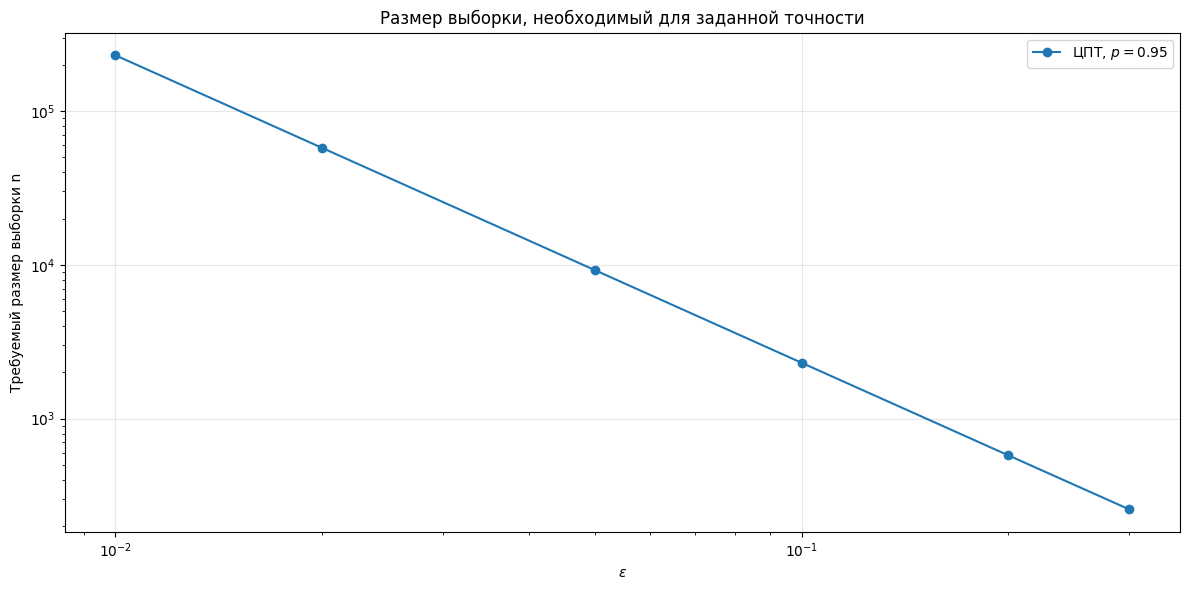

In [ ]:
eps_values = [0.3, 0.2, 0.1, 0.05, 0.02, 0.01]

print_required_sample_sizes(eps_values, p=0.95)
plot_required_sample_size_clt(eps_values, p=0.95)

И покажем заодно график, в котором мы симулируем несколько выборок одинаковых размеров и смотрим на их сходимость.

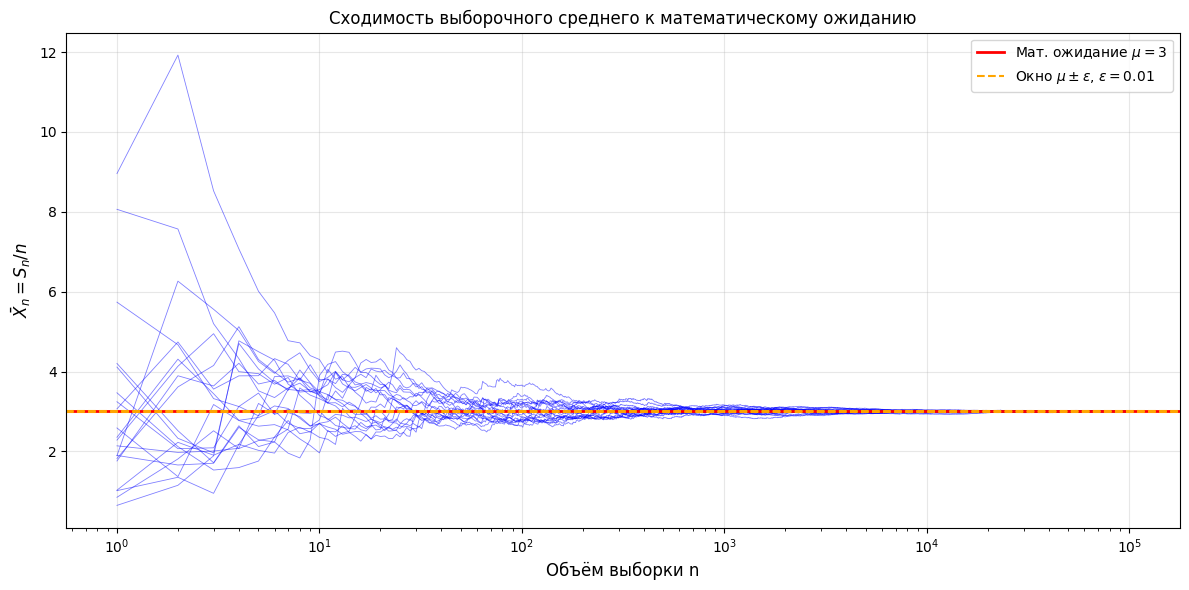

In [12]:
def plot_many_sample_means(sample_func, N=100000, M=20, target=3, epsilon=0.01):
    n_vals = np.arange(1, N + 1)

    plt.figure(figsize=(12, 6))

    for _ in range(M):
        sample_mean = sample_func(N=N)   
        plt.plot(n_vals, sample_mean, color='blue', linewidth=0.6, alpha=0.5)

    plt.axhline(y=target, color='red', linestyle='-', linewidth=2,
                label=fr'Мат. ожидание $\mu = {target}$')
    plt.axhline(y=target + epsilon, color='orange', linestyle='--', linewidth=1.5,
                label=fr'Окно $\mu \pm \varepsilon$, $\varepsilon={epsilon}$')
    plt.axhline(y=target - epsilon, color='orange', linestyle='--', linewidth=1.5)

    plt.xscale('log')
    plt.xlabel('Объём выборки n', fontsize=12)
    plt.ylabel(r'$\bar{X}_n = S_n/n$', fontsize=12)
    plt.title('Сходимость выборочного среднего к математическому ожиданию')
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_many_sample_means(sample)